In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K


# --------------------------------------------------------
# 1️⃣ Define Custom L2 Normalization Layer
# --------------------------------------------------------
class L2Normalization(Layer):
    def __init__(self, axis=-1, **kwargs):
        super(L2Normalization, self).__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.nn.l2_normalize(inputs, axis=self.axis)

    def get_config(self):
        config = super().get_config()
        config.update({"axis": self.axis})
        return config


# OPTIONAL: If your models include projection head or stop-gradient functions
# you can define placeholders (they are often identity layers in SSL)

class IdentityLayer(Layer):
    def call(self, x):
        return x


custom_objects = {
    "L2Normalization": L2Normalization,
    "IdentityLayer": IdentityLayer,
}


2025-12-07 14:26:25.341451: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765117585.533981      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765117585.581801      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
import os

base_dir = "/kaggle/input/alzeihmer-disease-model/other/default/1"

simclr_path = os.path.join(base_dir, "alzheimer_ssl_2 SimCLRmodel.h5")
simsam_path = os.path.join(base_dir, "alzheimer_ssl_3 -Simsiammodel.h5")
barlow_path = os.path.join(base_dir, "alzheimer_ssl_4- Barlow twinsmodel.h5")

print("Loading SSL Models with custom layers...")

simclr_model = tf.keras.models.load_model(simclr_path, custom_objects=custom_objects)
simsam_model = tf.keras.models.load_model(simsam_path, custom_objects=custom_objects)
barlow_model = tf.keras.models.load_model(barlow_path, custom_objects=custom_objects)

print("✅ All SSL models loaded successfully!")


Loading SSL Models with custom layers...


I0000 00:00:1765117602.183515      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✅ All SSL models loaded successfully!


In [3]:
# ============================================================
# Task 7 – Ratios, Ablations, and Statistics 
# ============================================================

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K
from scipy.stats import ttest_rel, wilcoxon, friedmanchisquare

# Nemenyi post-hoc
!pip install -q scikit-posthocs
import scikit_posthocs as sp

AUTOTUNE = tf.data.AUTOTUNE

# ------------------------------------------------------------
# 0. GLOBAL CONFIG
# ------------------------------------------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
TRAIN_RATIOS = [0.1, 0.25, 0.5, 1.0]

np.random.seed(42)
tf.random.set_seed(42)

# ------------------------------------------------------------
# 1. CUSTOM LAYERS FOR SSL MODELS
# ------------------------------------------------------------
class L2Normalization(Layer):
    def __init__(self, axis=-1, **kwargs):
        super(L2Normalization, self).__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.nn.l2_normalize(inputs, axis=self.axis)

    def get_config(self):
        config = super().get_config()
        config.update({"axis": self.axis})
        return config


class IdentityLayer(Layer):
    def call(self, x):
        return x


custom_objects = {
    "L2Normalization": L2Normalization,
    "IdentityLayer": IdentityLayer,
}

# ------------------------------------------------------------
# 2. PATHS ONLY (we’ll load models on demand)
# ------------------------------------------------------------
ssl_base_dir = "/kaggle/input/alzeihmer-disease-model/other/default/1"
SIMCLR_PATH  = os.path.join(ssl_base_dir, "alzheimer_ssl_2 SimCLRmodel.h5")
SIMSIAM_PATH = os.path.join(ssl_base_dir, "alzheimer_ssl_3 -Simsiammodel.h5")
BARLOW_PATH  = os.path.join(ssl_base_dir, "alzheimer_ssl_4- Barlow twinsmodel.h5")

print("SSL model files:\n", SIMCLR_PATH, "\n", SIMSIAM_PATH, "\n", BARLOW_PATH, "\n")

# ------------------------------------------------------------
# 3. DATASET LOADERS (STREAMING, NO NUMPY)
# ------------------------------------------------------------
train_root = "/kaggle/input/alzheimer-disease/train-20251010T183510Z-1-001/train"
test_root  = "/kaggle/input/alzheimer-disease/test-20251010T094612Z-1-001/test"

def make_full_train_ds(shuffle=True):
    ds = tf.keras.utils.image_dataset_from_directory(
        train_root,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=42,
    )
    return ds

def make_test_ds():
    ds = tf.keras.utils.image_dataset_from_directory(
        test_root,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )
    return ds.prefetch(AUTOTUNE)

# load once just to know classes
tmp_train = make_full_train_ds(shuffle=True)
class_names = tmp_train.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names, "| NUM_CLASSES:", NUM_CLASSES)

# cardinality (number of batches) – very cheap, no RAM issue
num_batches = tf.data.experimental.cardinality(tmp_train).numpy()
print("Train batches per epoch:", num_batches, "\n")

test_ds = make_test_ds()

# ------------------------------------------------------------
# 4. HELPERS: SUBSET DATASET BY RATIO
# ------------------------------------------------------------
def make_train_subset_ds(ratio):
    """
    Create a fresh streaming dataset that uses only `ratio`
    of the training batches (approximate per ratio, no RAM blow-up).
    """
    ds = make_full_train_ds(shuffle=True)
    n_take = max(1, int(num_batches * ratio))
    ds = ds.take(n_take)
    ds = ds.prefetch(AUTOTUNE)
    return ds

# ------------------------------------------------------------
# 5. LINEAR PROBE EVALUATION (LOAD MODEL INSIDE, CLEAR SESSION)
# ------------------------------------------------------------
def build_linear_probe(ssl_model, num_classes=NUM_CLASSES):
    ssl_model.trainable = False
    input_shape = ssl_model.input_shape[1:]
    inputs = tf.keras.Input(shape=input_shape, name=ssl_model.name + "_lp_input")
    x = ssl_model(inputs, training=False)
    if len(x.shape) > 2:
        x = tf.keras.layers.GlobalAveragePooling2D(name=ssl_model.name + "_lp_gap")(x)
    outputs = tf.keras.layers.Dense(
        num_classes,
        activation="softmax",
        name=ssl_model.name + "_lp_head",
    )(x)
    return tf.keras.Model(inputs, outputs, name=ssl_model.name + "_linear_probe")


def evaluate_ssl_from_path(
    model_path,
    train_ds,
    test_ds,
    epochs=5,
    lr=1e-3,
    optimizer_type="adam",
    model_label="ssl",
):
    """
    Load SSL model from disk, build linear probe, train & eval,
    then clear everything to save RAM.
    """
    # Clear out any previous graphs
    tf.keras.backend.clear_session()

    ssl_model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)
    ssl_model._name = model_label  # ensure name unique

    probe = build_linear_probe(ssl_model, NUM_CLASSES)

    if optimizer_type.lower() == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)

    probe.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    probe.fit(train_ds, epochs=epochs, verbose=0)
    loss, acc = probe.evaluate(test_ds, verbose=0)

    # Free memory aggressively
    del probe, ssl_model
    tf.keras.backend.clear_session()

    return acc

# ------------------------------------------------------------
# 6. RUN EXPERIMENT GRID: BASE VS ABLATION
# ------------------------------------------------------------
results = {
    "SimCLR": [],
    "SimCLR_abl": [],
    "SimSiam": [],
    "SimSiam_abl": [],
    "Barlow": [],
    "Barlow_abl": [],
}

print("Running downstream evaluations with low-RAM pipeline...\n")

for ratio in TRAIN_RATIOS:
    print(f"=== Train ratio: {ratio:.2f} ===")
    train_ds_ratio = make_train_subset_ds(ratio)

    # -------- SimCLR --------
    # Base: Adam, lr=1e-3, epochs=5
    acc_simclr = evaluate_ssl_from_path(
        SIMCLR_PATH,
        train_ds_ratio,
        test_ds,
        epochs=5,
        lr=1e-3,
        optimizer_type="adam",
        model_label=f"SimCLR_r{ratio}",
    )

    # Ablation: SGD, lr=0.01, epochs=5
    train_ds_ratio = make_train_subset_ds(ratio)
    acc_simclr_abl = evaluate_ssl_from_path(
        SIMCLR_PATH,
        train_ds_ratio,
        test_ds,
        epochs=5,
        lr=0.01,
        optimizer_type="sgd",
        model_label=f"SimCLRabl_r{ratio}",
    )

    # -------- SimSiam --------
    # Base: Adam, lr=1e-3, epochs=5
    train_ds_ratio = make_train_subset_ds(ratio)
    acc_simsiam = evaluate_ssl_from_path(
        SIMSIAM_PATH,
        train_ds_ratio,
        test_ds,
        epochs=5,
        lr=1e-3,
        optimizer_type="adam",
        model_label=f"SimSiam_r{ratio}",
    )

    # Ablation: fewer epochs (3)
    train_ds_ratio = make_train_subset_ds(ratio)
    acc_simsiam_abl = evaluate_ssl_from_path(
        SIMSIAM_PATH,
        train_ds_ratio,
        test_ds,
        epochs=3,
        lr=1e-3,
        optimizer_type="adam",
        model_label=f"SimSiamabl_r{ratio}",
    )

    # -------- Barlow Twins --------
    # Base: Adam, lr=1e-3, epochs=5
    train_ds_ratio = make_train_subset_ds(ratio)
    acc_barlow = evaluate_ssl_from_path(
        BARLOW_PATH,
        train_ds_ratio,
        test_ds,
        epochs=5,
        lr=1e-3,
        optimizer_type="adam",
        model_label=f"Barlow_r{ratio}",
    )

    # Ablation: fewer epochs (3)
    train_ds_ratio = make_train_subset_ds(ratio)
    acc_barlow_abl = evaluate_ssl_from_path(
        BARLOW_PATH,
        train_ds_ratio,
        test_ds,
        epochs=3,
        lr=1e-3,
        optimizer_type="adam",
        model_label=f"Barlowabl_r{ratio}",
    )

    results["SimCLR"].append(acc_simclr)
    results["SimCLR_abl"].append(acc_simclr_abl)
    results["SimSiam"].append(acc_simsiam)
    results["SimSiam_abl"].append(acc_simsiam_abl)
    results["Barlow"].append(acc_barlow)
    results["Barlow_abl"].append(acc_barlow_abl)

    print(f"SimCLR       base / abl: {acc_simclr:.4f} / {acc_simclr_abl:.4f}")
    print(f"SimSiam      base / abl: {acc_simsiam:.4f} / {acc_simsiam_abl:.4f}")
    print(f"Barlow Twins base / abl: {acc_barlow:.4f} / {acc_barlow_abl:.4f}\n")

print("✅ Finished all evaluations.\n")

# ------------------------------------------------------------
# 7. STATISTICAL TESTS
# ------------------------------------------------------------
simclr_scores      = np.array(results["SimCLR"])
simclr_abl_scores  = np.array(results["SimCLR_abl"])
simsiam_scores     = np.array(results["SimSiam"])
simsiam_abl_scores = np.array(results["SimSiam_abl"])
barlow_scores      = np.array(results["Barlow"])
barlow_abl_scores  = np.array(results["Barlow_abl"])

print("=== Scores by ratio ===")
for i, r in enumerate(TRAIN_RATIOS):
    print(
        f"Ratio {r:.2f}: "
        f"SimCLR {simclr_scores[i]:.4f} | SimCLR_abl {simclr_abl_scores[i]:.4f} | "
        f"SimSiam {simsiam_scores[i]:.4f} | SimSiam_abl {simsiam_abl_scores[i]:.4f} | "
        f"Barlow {barlow_scores[i]:.4f} | Barlow_abl {barlow_abl_scores[i]:.4f}"
    )
print()

# Paired t-test: SimCLR vs SimSiam (base)
t_stat, p_val = ttest_rel(simclr_scores, simsiam_scores)
print("Paired t-test: SimCLR vs SimSiam (base)")
print(f"t = {t_stat:.4f}, p = {p_val:.6f}\n")

# Wilcoxon: base vs ablation for each SSL
w_stat, p_val = wilcoxon(simclr_scores, simclr_abl_scores)
print("Wilcoxon: SimCLR base vs SimCLR ablation")
print(f"W = {w_stat:.4f}, p = {p_val:.6f}\n")

w_stat, p_val = wilcoxon(simsiam_scores, simsiam_abl_scores)
print("Wilcoxon: SimSiam base vs SimSiam ablation")
print(f"W = {w_stat:.4f}, p = {p_val:.6f}\n")

w_stat, p_val = wilcoxon(barlow_scores, barlow_abl_scores)
print("Wilcoxon: Barlow base vs Barlow ablation")
print(f"W = {w_stat:.4f}, p = {p_val:.6f}\n")

# Friedman: compare 3 base models
fried_stat, fried_p = friedmanchisquare(
    simclr_scores,
    simsiam_scores,
    barlow_scores
)
print("Friedman test (SimCLR, SimSiam, Barlow – base models)")
print(f"χ² = {fried_stat:.4f}, p = {fried_p:.6f}\n")

# Nemenyi post-hoc
data_for_nemenyi = np.vstack([simclr_scores, simsiam_scores, barlow_scores]).T
nemenyi_matrix = sp.posthoc_nemenyi_friedman(data_for_nemenyi)
print("Nemenyi post-hoc p-value matrix (rows/cols: SimCLR, SimSiam, Barlow):")
print(nemenyi_matrix)


SSL model files:
 /kaggle/input/alzeihmer-disease-model/other/default/1/alzheimer_ssl_2 SimCLRmodel.h5 
 /kaggle/input/alzeihmer-disease-model/other/default/1/alzheimer_ssl_3 -Simsiammodel.h5 
 /kaggle/input/alzeihmer-disease-model/other/default/1/alzheimer_ssl_4- Barlow twinsmodel.h5 

Found 4123 files belonging to 3 classes.
Classes: ['AD', 'CN', 'MCI'] | NUM_CLASSES: 3
Train batches per epoch: 129 

Found 1031 files belonging to 3 classes.
Running downstream evaluations with low-RAM pipeline...

=== Train ratio: 0.10 ===
Found 4123 files belonging to 3 classes.


I0000 00:00:1765117656.313915      60 service.cc:148] XLA service 0x7e3f84003440 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765117656.314548      60 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1765117661.026251      60 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1765117682.265789      60 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Found 4123 files belonging to 3 classes.


Found 4123 files belonging to 3 classes.


Found 4123 files belonging to 3 classes.


...

Found 4123 files belonging to 3 classes.


Found 4123 files belonging to 3 classes.


Found 4123 files belonging to 3 classes.


Found 4123 files belonging to 3 classes.


SimCLR       base / abl: 0.2939 / 0.9612
SimSiam      base / abl: 0.3725 / 0.2793
Barlow Twins base / abl: 0.5024 / 0.3453

✅ Finished all evaluations.

=== Scores by ratio ===
Ratio 0.10: SimCLR 0.2793 | SimCLR_abl 0.2667 | SimSiam 0.2182 | SimSiam_abl 0.2793 | Barlow 0.2182 | Barlow_abl 0.5024
Ratio 0.25: SimCLR 0.2793 | SimCLR_abl 0.5694 | SimSiam 0.5024 | SimSiam_abl 0.2793 | Barlow 0.2570 | Barlow_abl 0.2182
Ratio 0.50: SimCLR 0.5034 | SimCLR_abl 0.2347 | SimSiam 0.2803 | SimSiam_abl 0.2793 | Barlow 0.5024 | Barlow_abl 0.3094
Ratio 1.00: SimCLR 0.2939 | SimCLR_abl 0.9612 | SimSiam 0.3725 | SimSiam_abl 0.2793 | Barlow 0.5024 | Barlow_abl 0.3453

Paired t-test: SimCLR vs SimSiam (base)
t = -0.0457, p = 0.966406

Wilcoxon: SimCLR base vs SimCLR ablation
W = 3.0000, p = 0.625000

Wilcoxon: SimSiam base vs SimSiam ablation
W = 2.0000, p = 0.375000

Wilcoxon: Barlow base vs Barlow ablation
W = 4.0000, p = 0.875000

Friedman test (SimCLR, SimSiam, Barlow – base models)
χ² = 0.4000, p = 0

Found 4123 files belonging to 3 classes.
Found 1031 files belonging to 3 classes.
Best base SSL at full labels: Barlow (acc=0.5024)
Found 4123 files belonging to 3 classes.


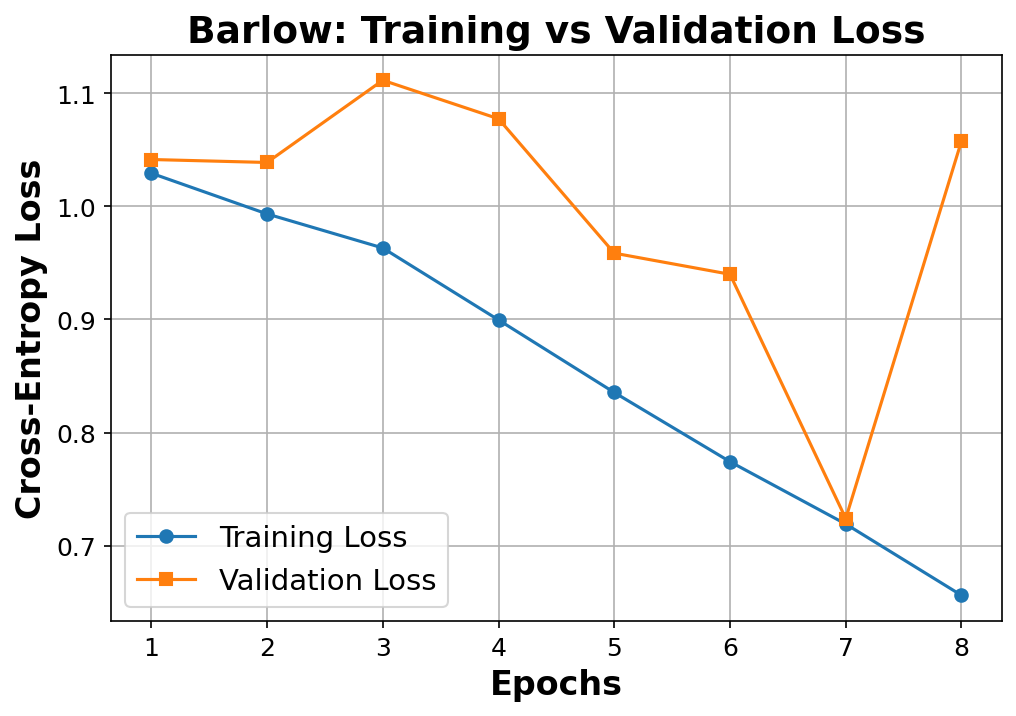

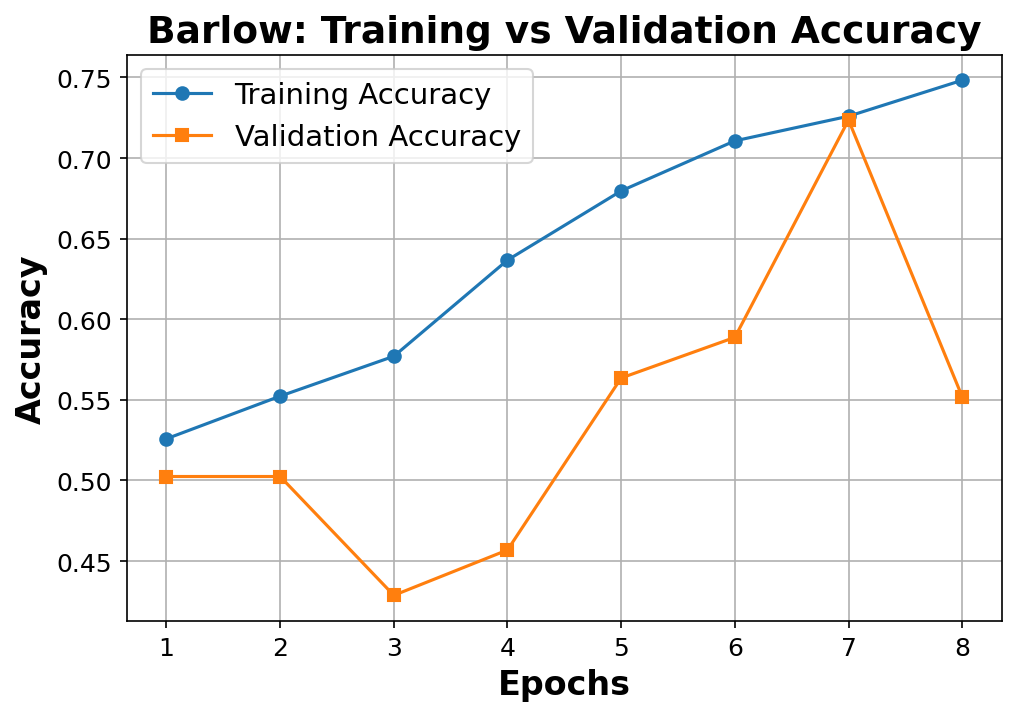

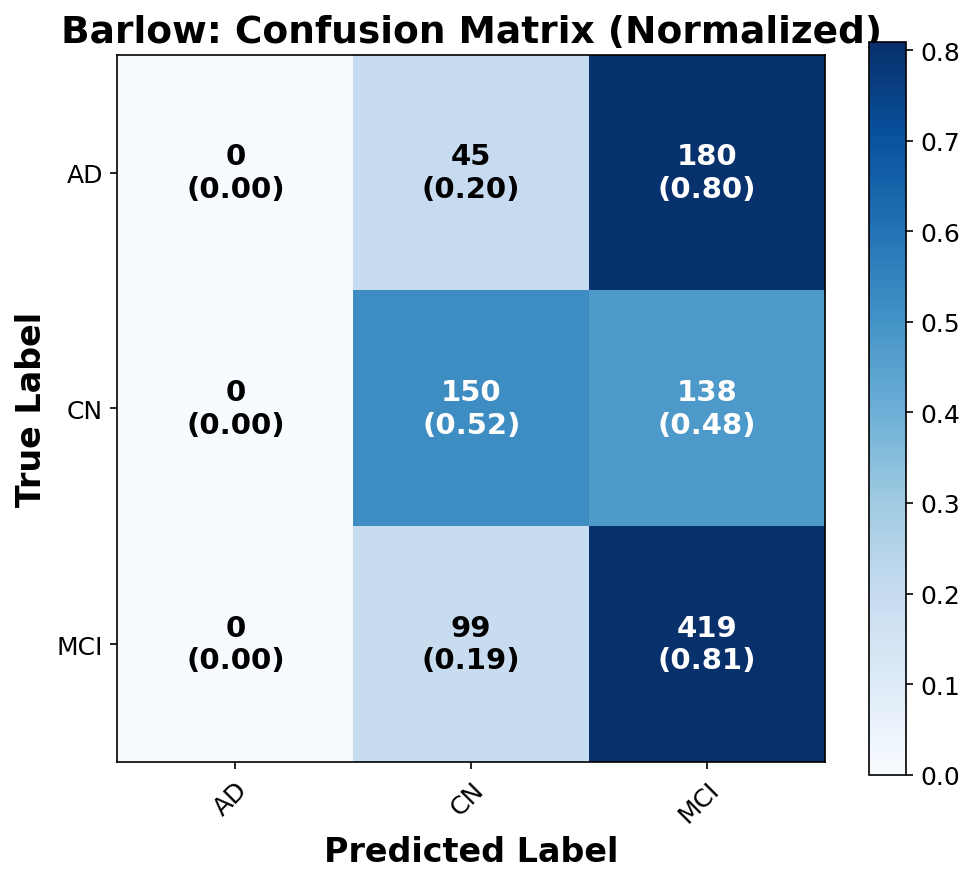

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


,precision,recall,f1-score,support
AD,0.000000,0.000000,0.000000,225.000000
CN,0.510204,0.520833,0.515464,288.000000
MCI,0.568521,0.808880,0.667729,518.000000
accuracy,0.551891,0.551891,0.551891,0.551891
macro avg,0.359575,0.443238,0.394398,1031.000000
weighted avg,0.428160,0.551891,0.479474,1031.000000


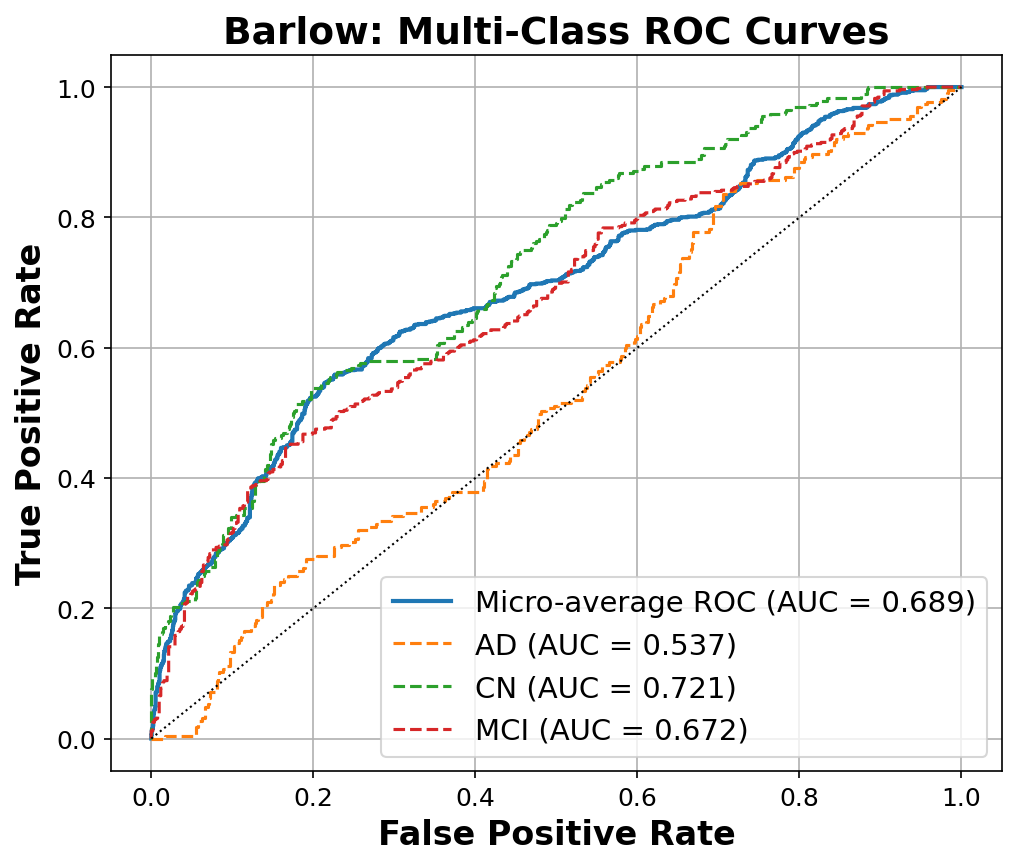

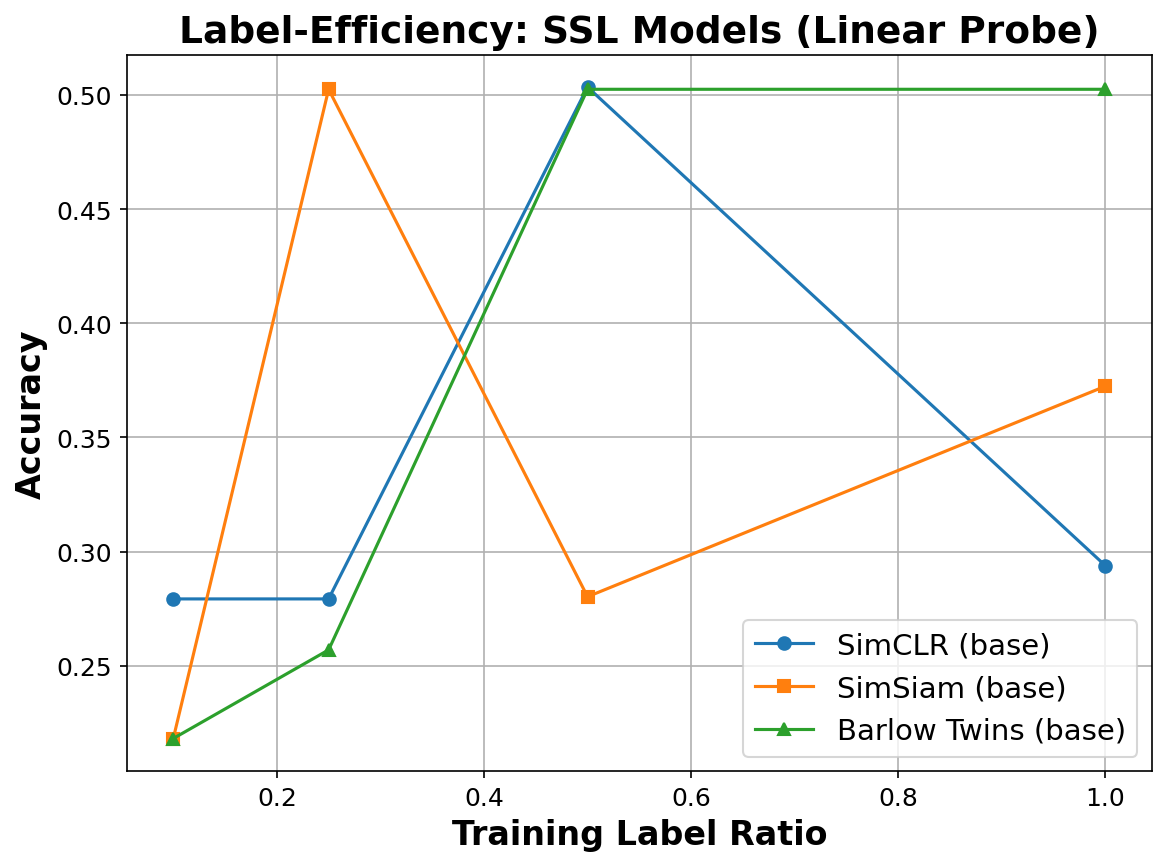

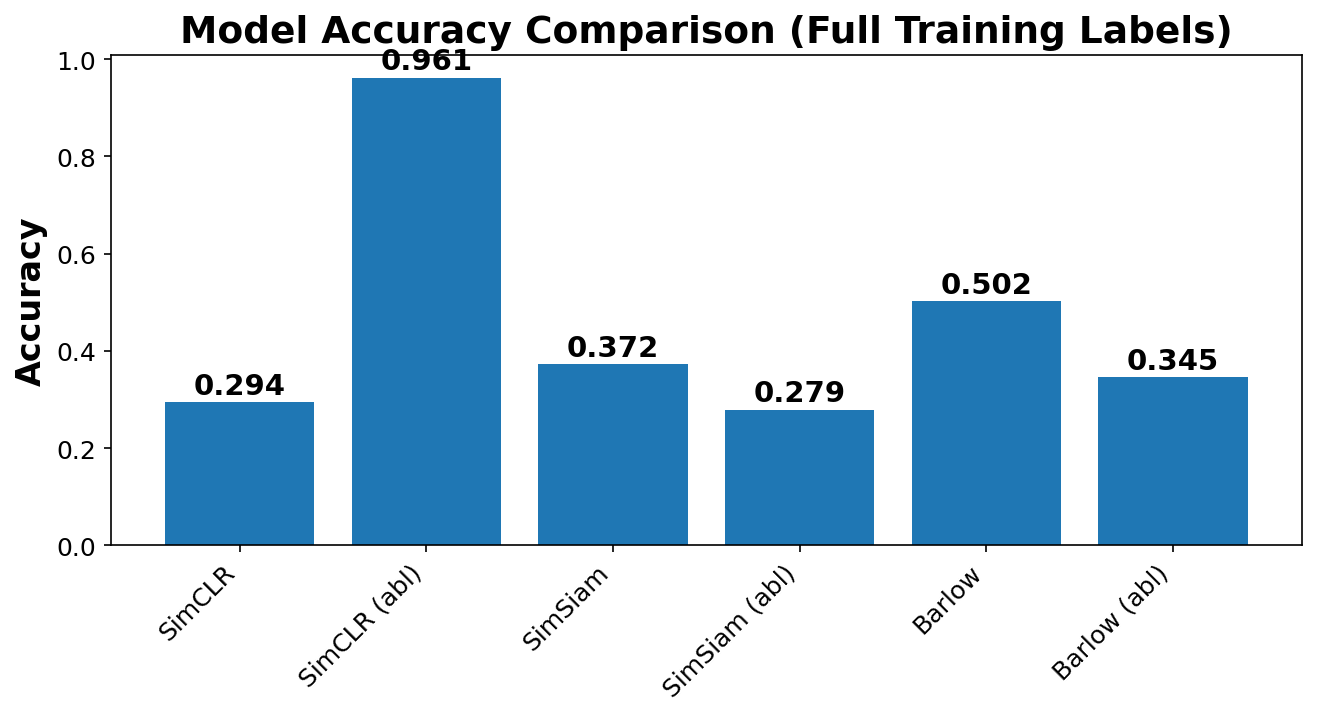

In [4]:
# ============================================================
# VISUALIZATIONS FOR IEEE PAPER (BEST MODEL + COMPARISONS)
# ============================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize

# ---------- GLOBAL MATPLOTLIB STYLE (BOLD / BIGGER FONTS) ----------
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "axes.labelweight": "bold",
    "legend.fontsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 150,
})

AUTOTUNE = tf.data.AUTOTUNE

# Make sure these match your earlier cell
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_root = "/kaggle/input/alzheimer-disease/train-20251010T183510Z-1-001/train"
test_root  = "/kaggle/input/alzheimer-disease/test-20251010T094612Z-1-001/test"

ssl_base_dir = "/kaggle/input/alzeihmer-disease-model/other/default/1"
SIMCLR_PATH  = os.path.join(ssl_base_dir, "alzheimer_ssl_2 SimCLRmodel.h5")
SIMSIAM_PATH = os.path.join(ssl_base_dir, "alzheimer_ssl_3 -Simsiammodel.h5")
BARLOW_PATH  = os.path.join(ssl_base_dir, "alzheimer_ssl_4- Barlow twinsmodel.h5")

# ---------- 1) DATA HELPERS (STREAMING) ----------
def make_full_train_ds(shuffle=True):
    ds = tf.keras.utils.image_dataset_from_directory(
        train_root,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=42,
    )
    return ds

def make_test_ds():
    ds = tf.keras.utils.image_dataset_from_directory(
        test_root,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )
    return ds.prefetch(AUTOTUNE)

# load once to get classes
tmp_ds = make_full_train_ds(shuffle=True)
class_names = tmp_ds.class_names
NUM_CLASSES = len(class_names)

def make_train_subset_ds(ratio):
    num_batches = tf.data.experimental.cardinality(tmp_ds).numpy()
    n_take = max(1, int(num_batches * ratio))
    ds = make_full_train_ds(shuffle=True)
    ds = ds.take(n_take).prefetch(AUTOTUNE)
    return ds

test_ds = make_test_ds()

# ---------- 2) CUSTOM LAYERS (same as before) ----------
from tensorflow.keras.layers import Layer

class L2Normalization(Layer):
    def __init__(self, axis=-1, **kwargs):
        super(L2Normalization, self).__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.nn.l2_normalize(inputs, axis=self.axis)

    def get_config(self):
        config = super().get_config()
        config.update({"axis": self.axis})
        return config

class IdentityLayer(Layer):
    def call(self, x):
        return x

custom_objects = {
    "L2Normalization": L2Normalization,
    "IdentityLayer": IdentityLayer,
}

# ---------- 3) PICK BEST SSL BASE MODEL (ratio = 1.0) ----------
# These arrays come from your Task-7 cell
base_full_accs = [
    simclr_scores[-1],
    simsiam_scores[-1],
    barlow_scores[-1],
]
base_names = ["SimCLR", "SimSiam", "Barlow"]
base_paths = [SIMCLR_PATH, SIMSIAM_PATH, BARLOW_PATH]

best_idx = int(np.argmax(base_full_accs))
best_name = base_names[best_idx]
best_path = base_paths[best_idx]

print(f"Best base SSL at full labels: {best_name} (acc={base_full_accs[best_idx]:.4f})")

# ---------- 4) TRAIN BEST MODEL PROBE WITH HISTORY & PREDICTIONS ----------
def build_linear_probe(ssl_model, num_classes=NUM_CLASSES):
    ssl_model.trainable = False
    input_shape = ssl_model.input_shape[1:]
    inputs = tf.keras.Input(shape=input_shape, name=ssl_model.name + "_lp_input")
    x = ssl_model(inputs, training=False)
    if len(x.shape) > 2:
        x = tf.keras.layers.GlobalAveragePooling2D(name=ssl_model.name + "_lp_gap")(x)
    outputs = tf.keras.layers.Dense(
        num_classes,
        activation="softmax",
        name=ssl_model.name + "_lp_head",
    )(x)
    return tf.keras.Model(inputs, outputs, name=ssl_model.name + "_linear_probe")


def train_best_model_with_history(
    model_path,
    ratio=1.0,
    epochs=8,
    lr=1e-3,
    optimizer_type="adam",
    label="BestSSL",
):
    tf.keras.backend.clear_session()

    train_ds_ratio = make_train_subset_ds(ratio)

    ssl_model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)
    ssl_model._name = label

    probe = build_linear_probe(ssl_model, NUM_CLASSES)

    if optimizer_type.lower() == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)

    probe.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    # Use test_ds as validation to obtain curves (for plotting only)
    history = probe.fit(
        train_ds_ratio,
        epochs=epochs,
        validation_data=test_ds,
        verbose=0,
    )

    # Collect predictions on the test set
    y_true = []
    y_prob = []
    for x_batch, y_batch in test_ds:
        preds = probe.predict(x_batch, verbose=0)
        y_prob.append(preds)
        y_true.append(y_batch.numpy())

    y_prob = np.vstack(y_prob)
    y_true = np.concatenate(y_true)
    y_pred = np.argmax(y_prob, axis=1)

    # clean up
    del probe, ssl_model
    tf.keras.backend.clear_session()

    return history.history, y_true, y_pred, y_prob

history_dict, y_true, y_pred, y_prob = train_best_model_with_history(
    best_path,
    ratio=1.0,
    epochs=8,
    lr=1e-3,
    optimizer_type="adam",
    label=best_name + "_best",
)

# ============================================================
# A) TRAIN–VALIDATION CURVES
# ============================================================
epochs_range = range(1, len(history_dict["loss"]) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history_dict["loss"], marker="o", label="Training Loss")
plt.plot(epochs_range, history_dict["val_loss"], marker="s", label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Cross-Entropy Loss")
plt.title(f"{best_name}: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history_dict["accuracy"], marker="o", label="Training Accuracy")
plt.plot(epochs_range, history_dict["val_accuracy"], marker="s", label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title(f"{best_name}: Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# B) CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues")
ax.figure.colorbar(im, ax=ax)

ax.set(
    xticks=np.arange(NUM_CLASSES),
    yticks=np.arange(NUM_CLASSES),
    xticklabels=class_names,
    yticklabels=class_names,
    ylabel="True Label",
    xlabel="Predicted Label",
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# annotate each cell
thresh = cm_norm.max() / 2.0
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(
            j, i,
            f"{cm[i, j]}\n({cm_norm[i, j]:.2f})",
            ha="center",
            va="center",
            color="white" if cm_norm[i, j] > thresh else "black",
            fontweight="bold",
        )

ax.set_title(f"{best_name}: Confusion Matrix (Normalized)")
fig.tight_layout()
plt.show()

# ============================================================
# C) CLASSIFICATION REPORT TABLE (PRECISION / RECALL / F1 / SUPPORT)
# ============================================================
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df)

# ============================================================
# D) ROC CURVES (ONE-VS-REST MULTI-CLASS)
# ============================================================
y_true_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(7, 6))
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label=f"Micro-average ROC (AUC = {roc_auc['micro']:.3f})",
    linewidth=2,
)

for i in range(NUM_CLASSES):
    plt.plot(
        fpr[i],
        tpr[i],
        linestyle="--",
        linewidth=1.5,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})",
    )

plt.plot([0, 1], [0, 1], "k:", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"{best_name}: Multi-Class ROC Curves")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# E) LABEL-EFFICIENCY CURVES (ACCURACY vs TRAIN RATIO)
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(TRAIN_RATIOS, simclr_scores, marker="o", label="SimCLR (base)")
plt.plot(TRAIN_RATIOS, simsiam_scores, marker="s", label="SimSiam (base)")
plt.plot(TRAIN_RATIOS, barlow_scores, marker="^", label="Barlow Twins (base)")

plt.xlabel("Training Label Ratio")
plt.ylabel("Accuracy")
plt.title("Label-Efficiency: SSL Models (Linear Probe)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# F) MODEL ACCURACY COMPARISON AT FULL LABELS
# ============================================================
full_accs = [
    simclr_scores[-1],
    simclr_abl_scores[-1],
    simsiam_scores[-1],
    simsiam_abl_scores[-1],
    barlow_scores[-1],
    barlow_abl_scores[-1],
]
model_labels = [
    "SimCLR",
    "SimCLR (abl)",
    "SimSiam",
    "SimSiam (abl)",
    "Barlow",
    "Barlow (abl)",
]

plt.figure(figsize=(9, 5))
bars = plt.bar(np.arange(len(model_labels)), full_accs)
plt.xticks(np.arange(len(model_labels)), model_labels, rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (Full Training Labels)")

# annotate bars
for bar, acc in zip(bars, full_accs):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{acc:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()


Found 4123 files belonging to 3 classes.
Classes: ['AD', 'CN', 'MCI']
Train batches per epoch: 129
Found 1031 files belonging to 3 classes.

=== Processing SimCLR (ratio=1.0) ===
Found 4123 files belonging to 3 classes.


SimCLR – final val_accuracy: 0.6111
Found 4123 files belonging to 3 classes.

=== Processing SimSiam (ratio=1.0) ===
Found 4123 files belonging to 3 classes.


SimSiam – final val_accuracy: 0.5626
Found 4123 files belonging to 3 classes.

=== Processing Barlow (ratio=1.0) ===
Found 4123 files belonging to 3 classes.


Barlow – final val_accuracy: 0.7003
Found 4123 files belonging to 3 classes.


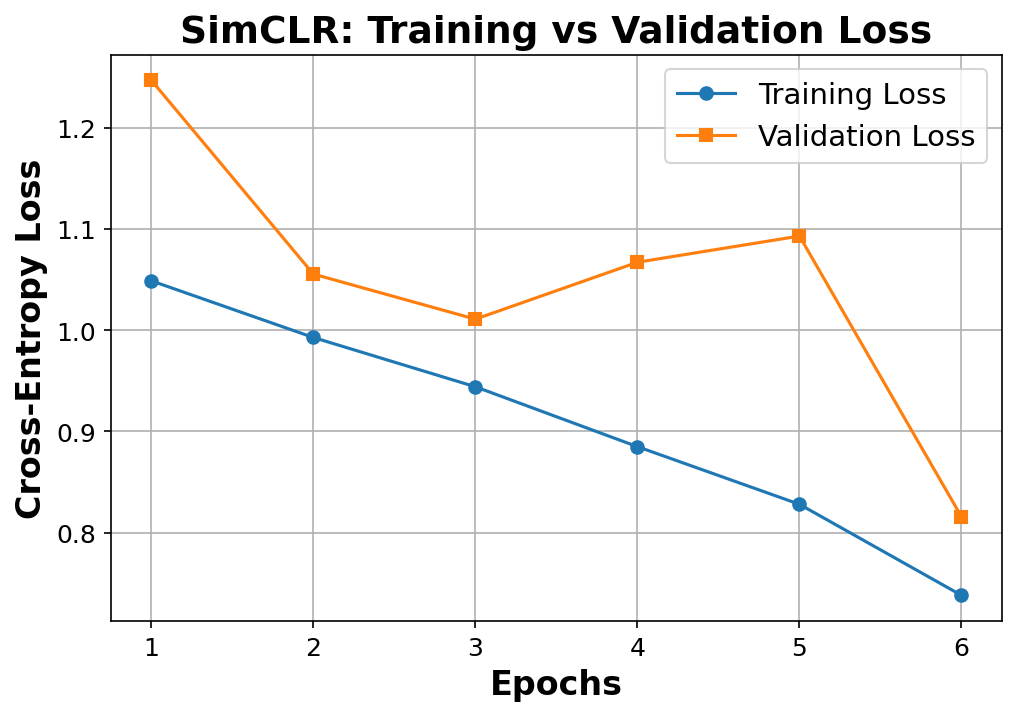

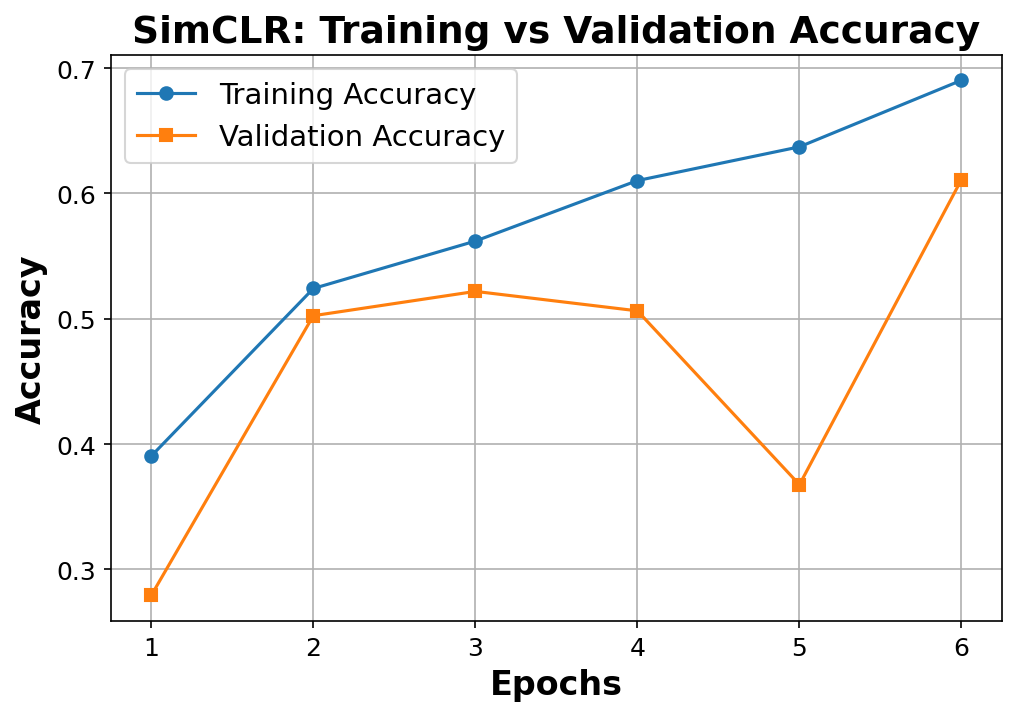

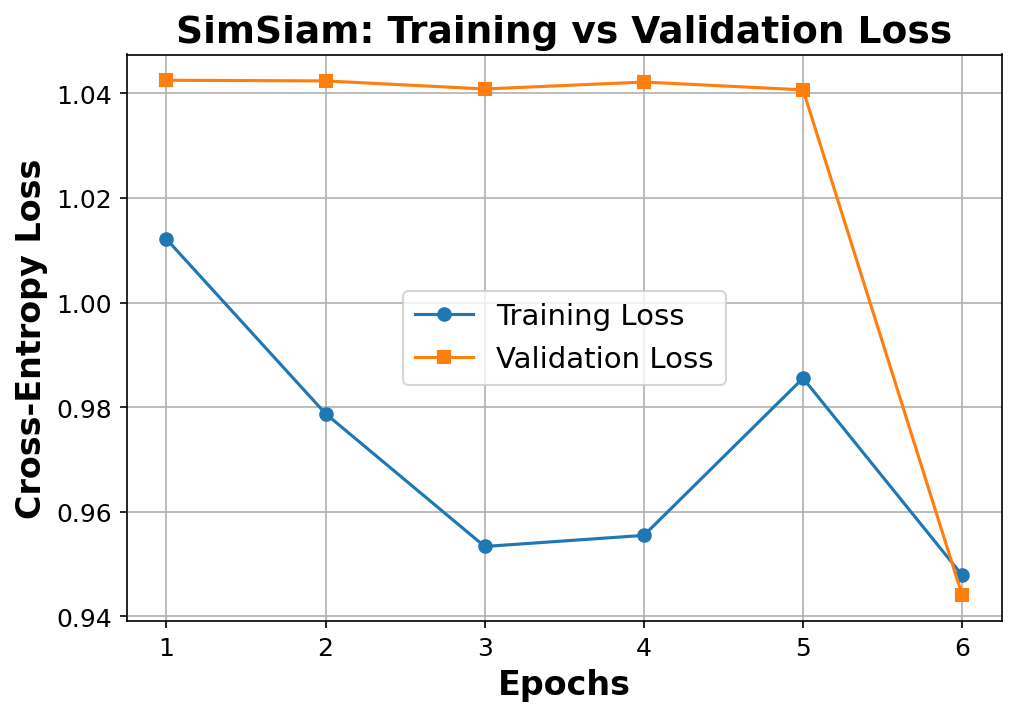

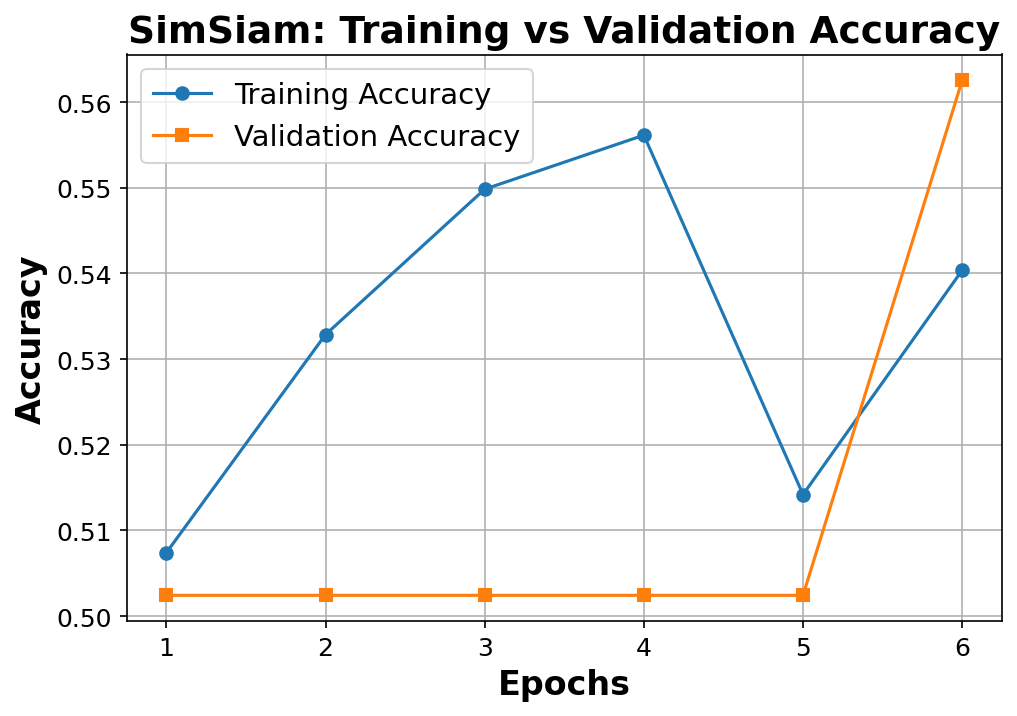

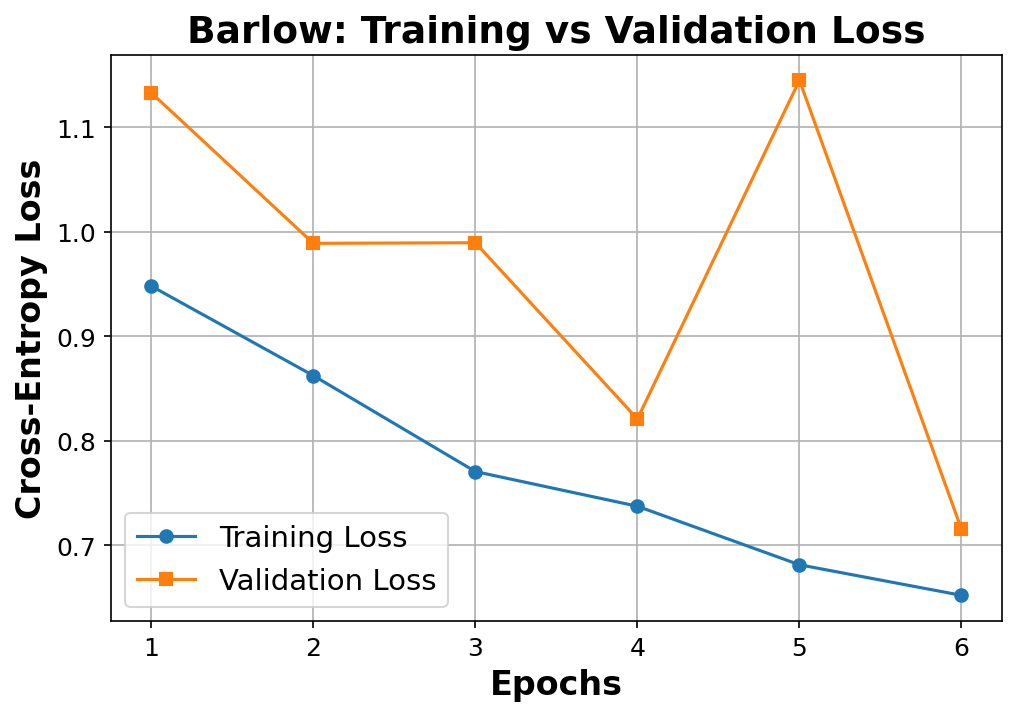

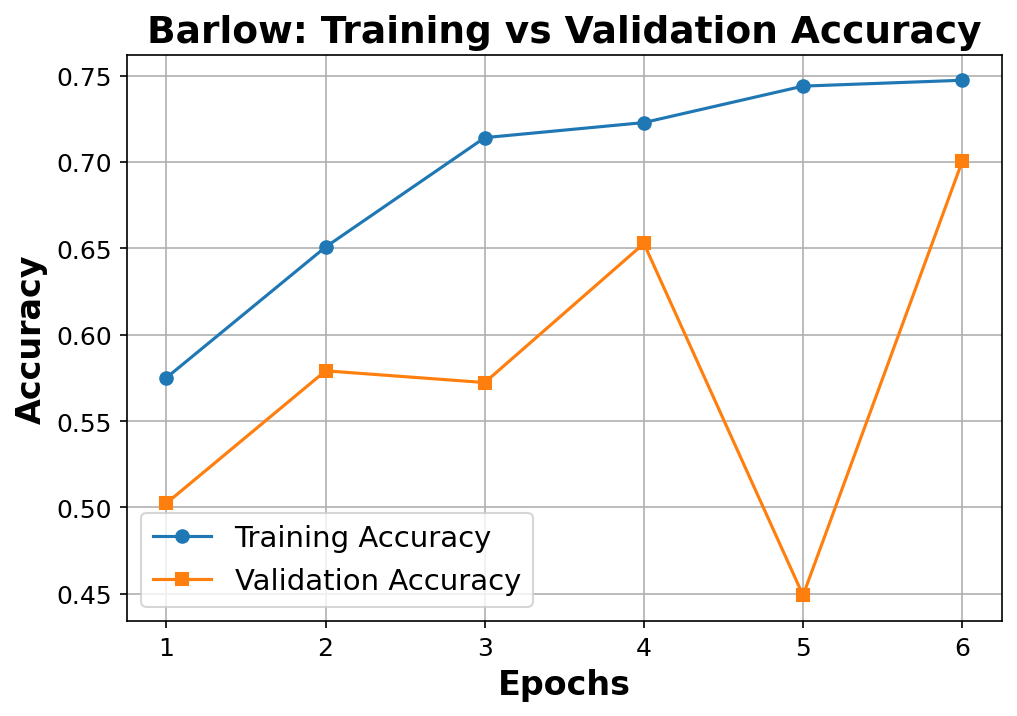

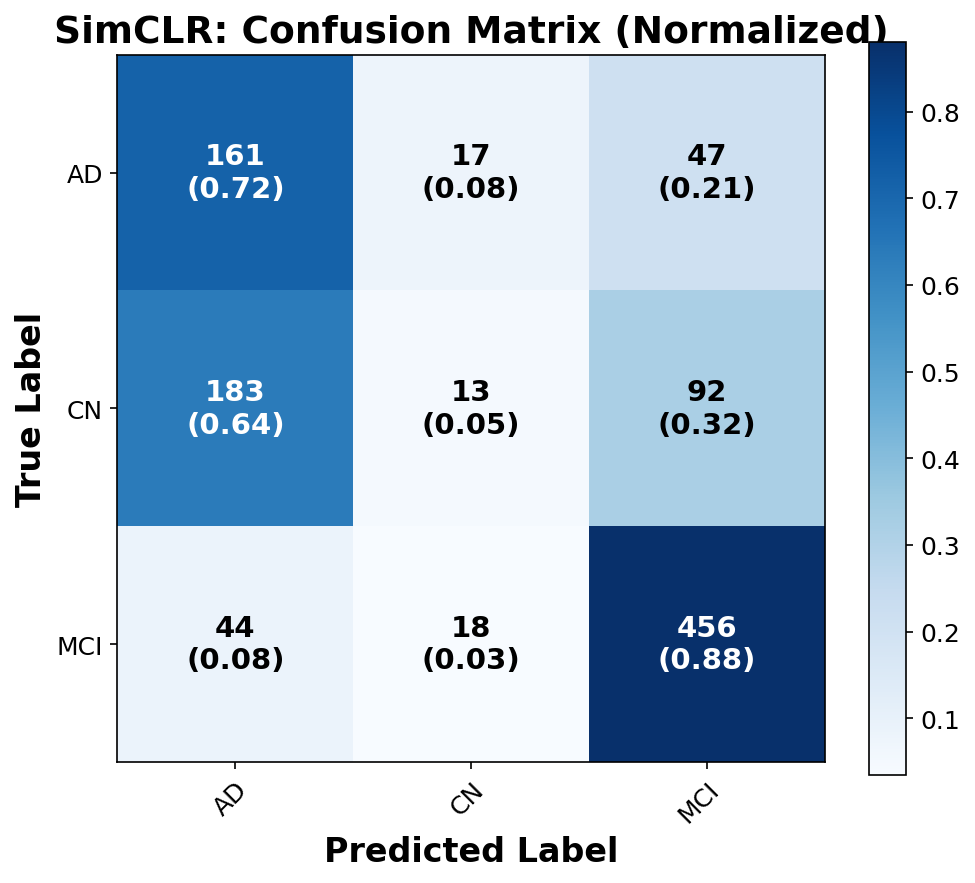


=== Classification Report: SimCLR ===


,precision,recall,f1-score,support
AD,0.414948,0.715556,0.525285,225.000000
CN,0.270833,0.045139,0.077381,288.000000
MCI,0.766387,0.880309,0.819407,518.000000
accuracy,0.611057,0.611057,0.611057,0.611057
macro avg,0.484056,0.547001,0.474024,1031.000000
weighted avg,0.551262,0.611057,0.547942,1031.000000


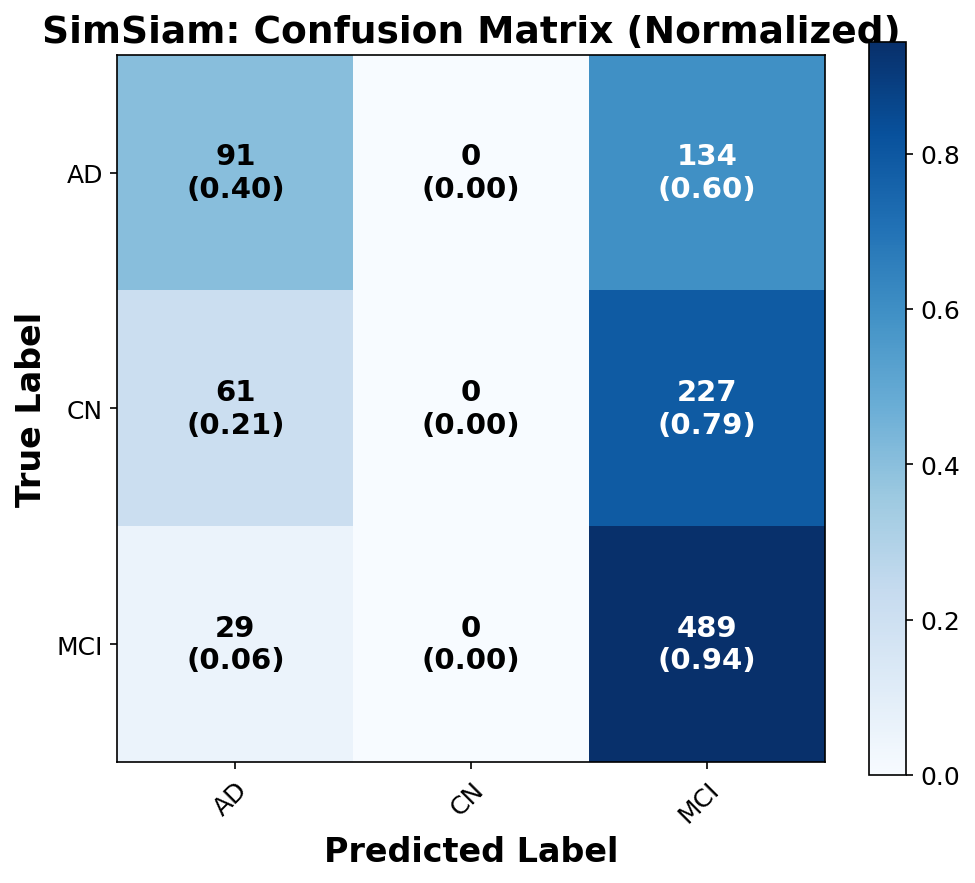


=== Classification Report: SimSiam ===


,precision,recall,f1-score,support
AD,0.502762,0.404444,0.448276,225.000000
CN,0.000000,0.000000,0.000000,288.000000
MCI,0.575294,0.944015,0.714912,518.000000
accuracy,0.562561,0.562561,0.562561,0.562561
macro avg,0.359352,0.449487,0.387729,1031.000000
weighted avg,0.398762,0.562561,0.457019,1031.000000


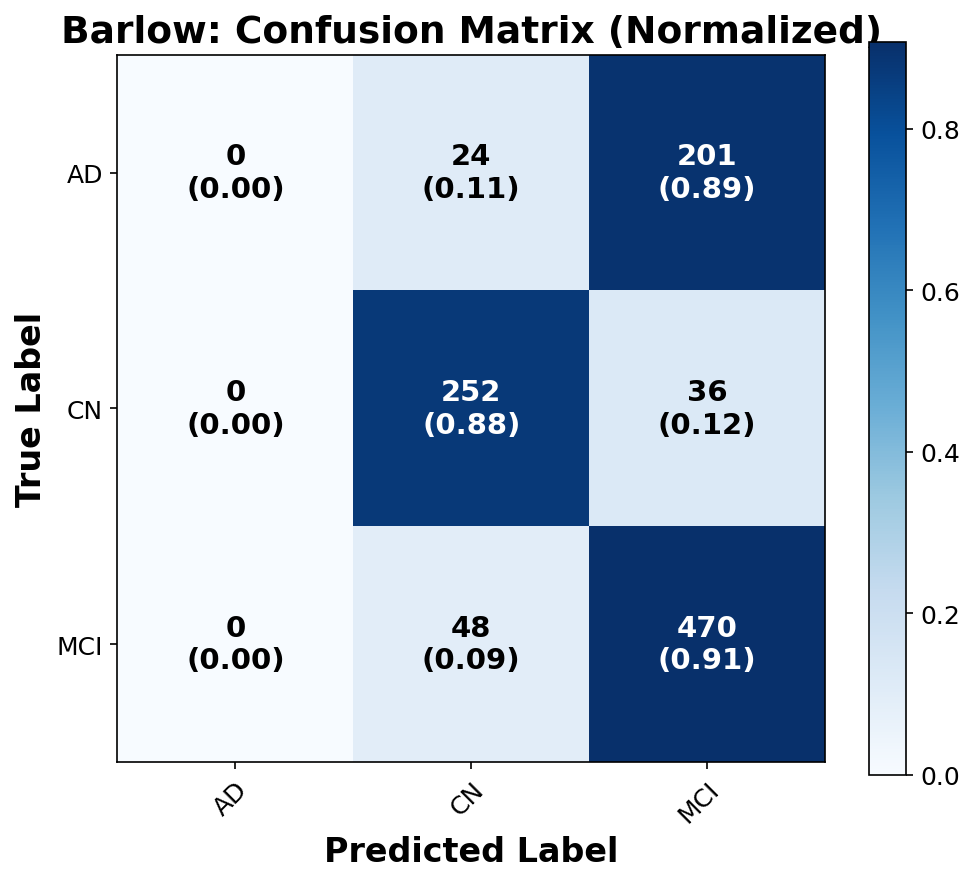


=== Classification Report: Barlow ===


,precision,recall,f1-score,support
AD,0.000000,0.000000,0.000000,225.000000
CN,0.777778,0.875000,0.823529,288.000000
MCI,0.664781,0.907336,0.767347,518.000000
accuracy,0.700291,0.700291,0.700291,0.700291
macro avg,0.480853,0.594112,0.530292,1031.000000
weighted avg,0.551267,0.700291,0.615579,1031.000000


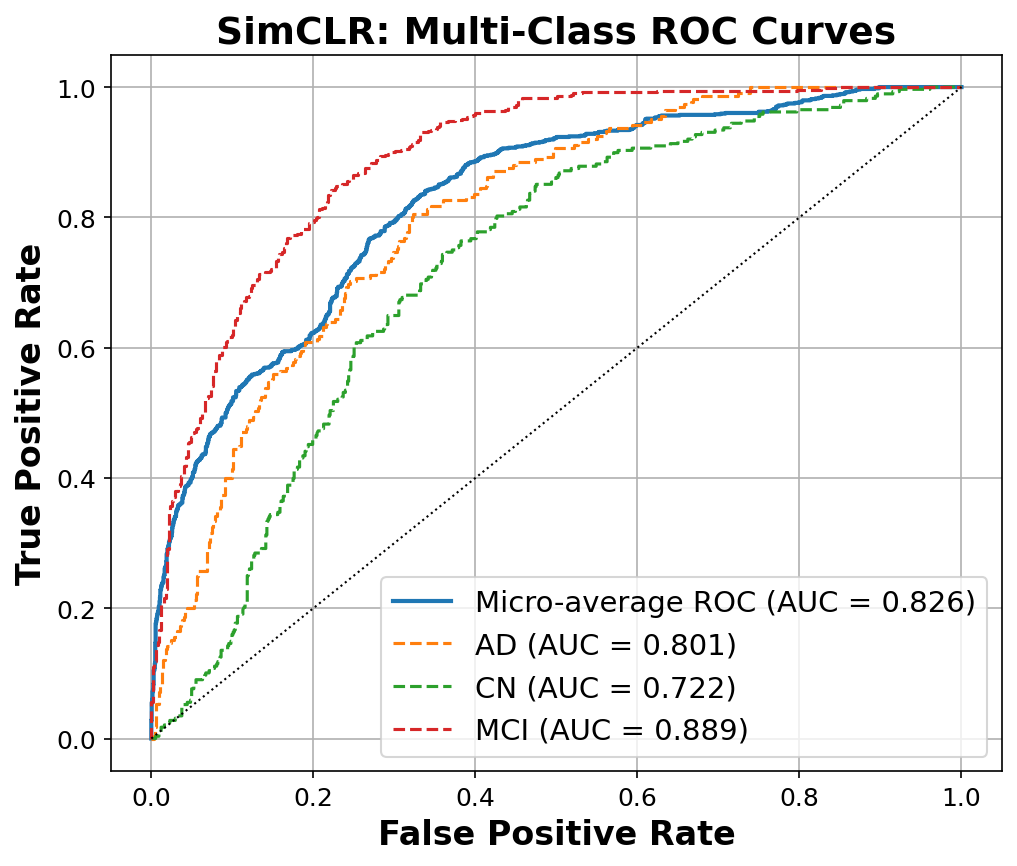

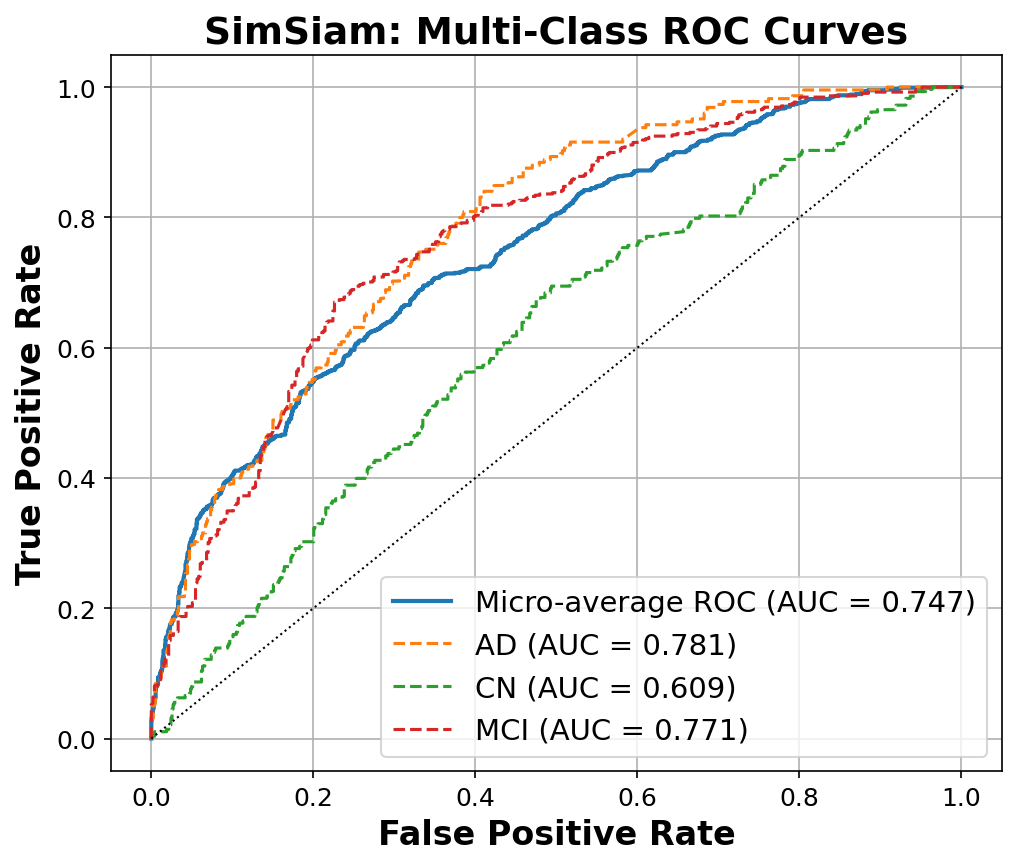

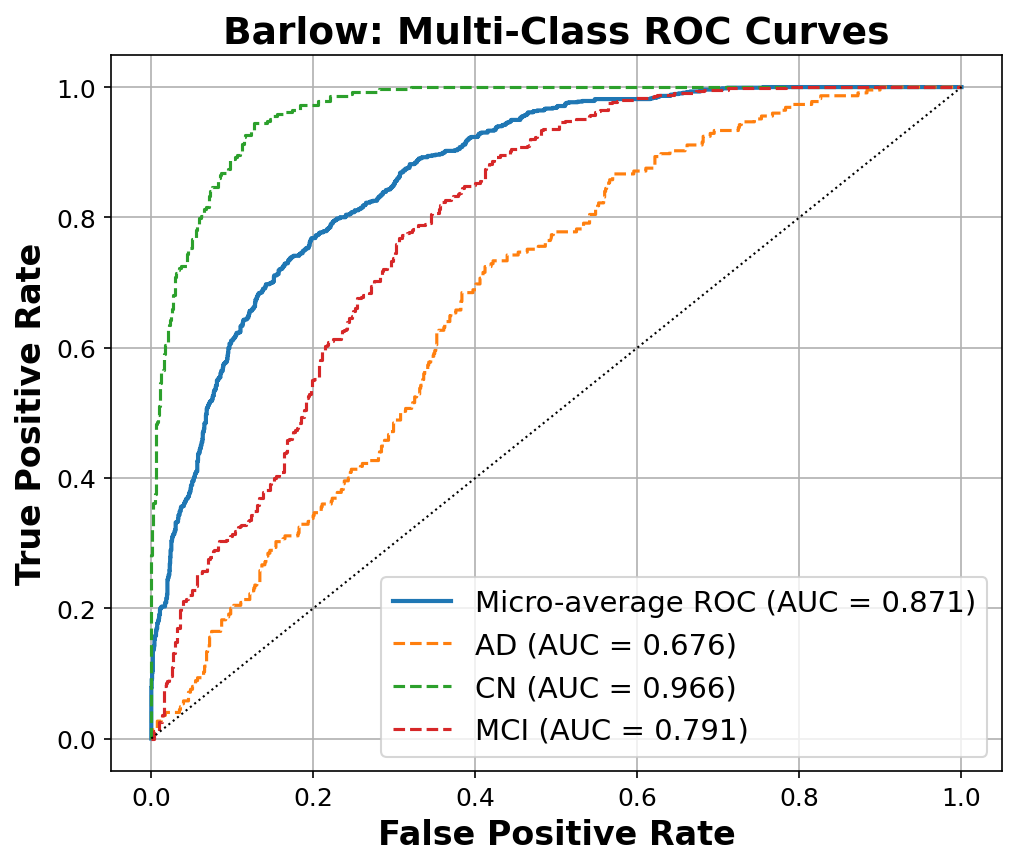

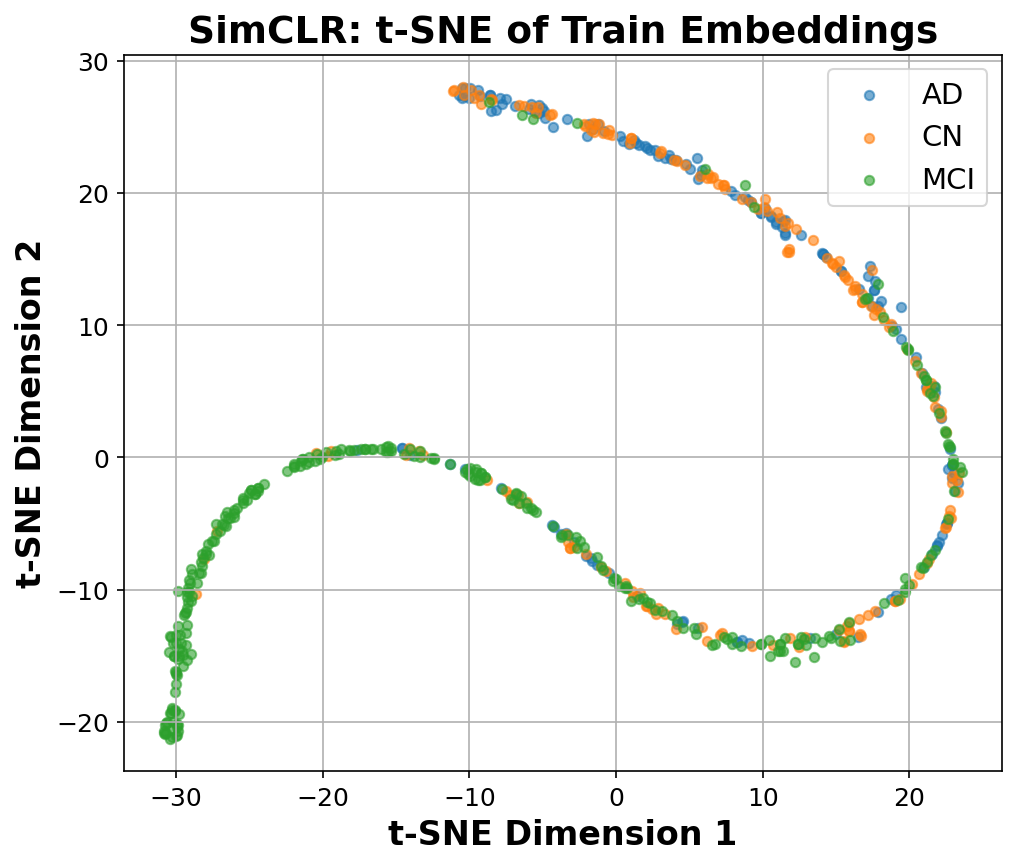

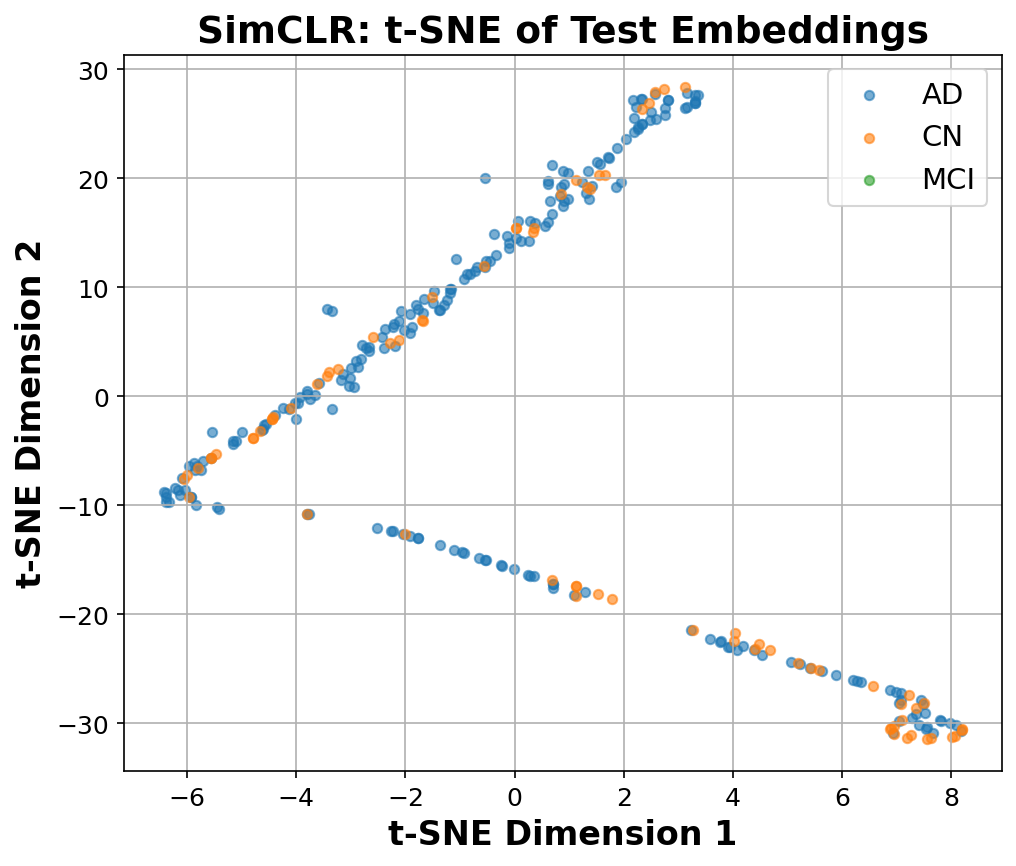

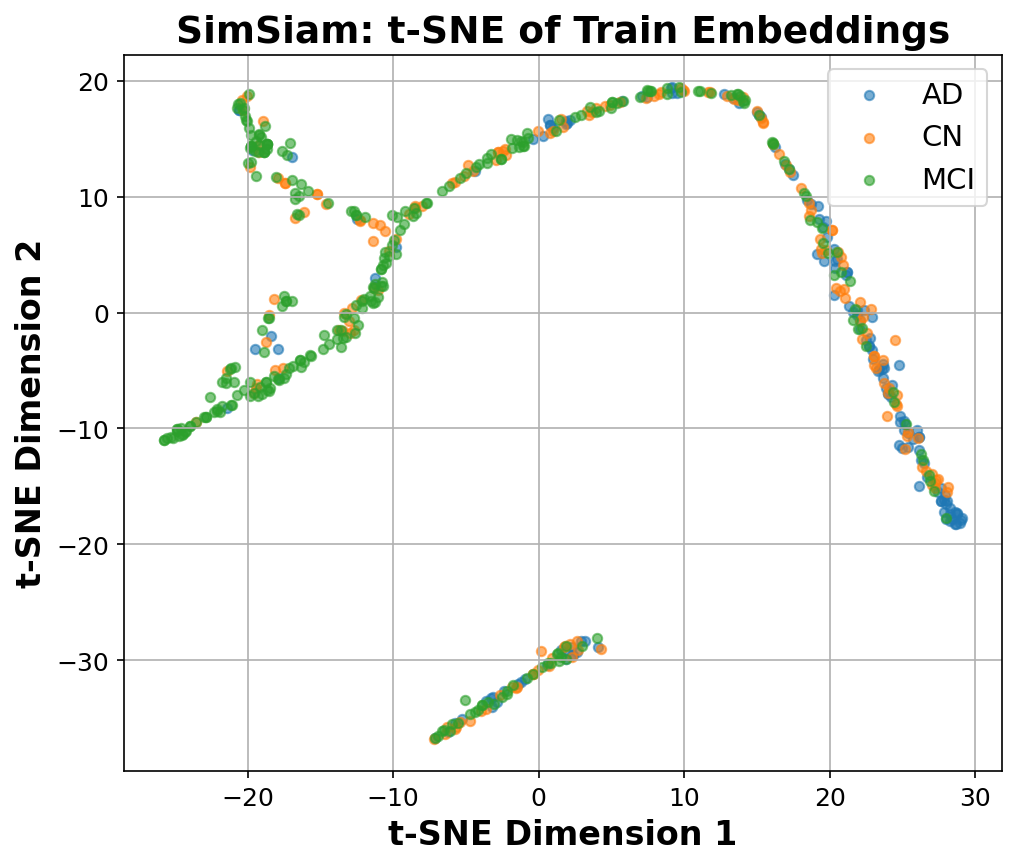

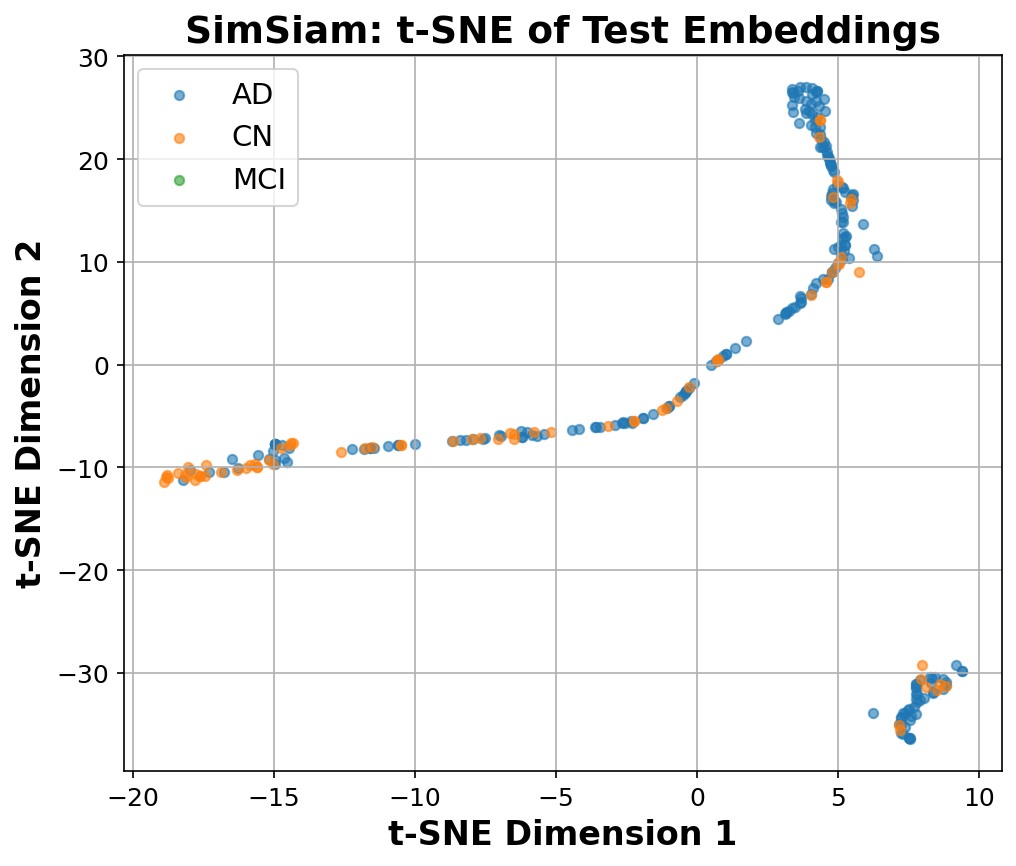

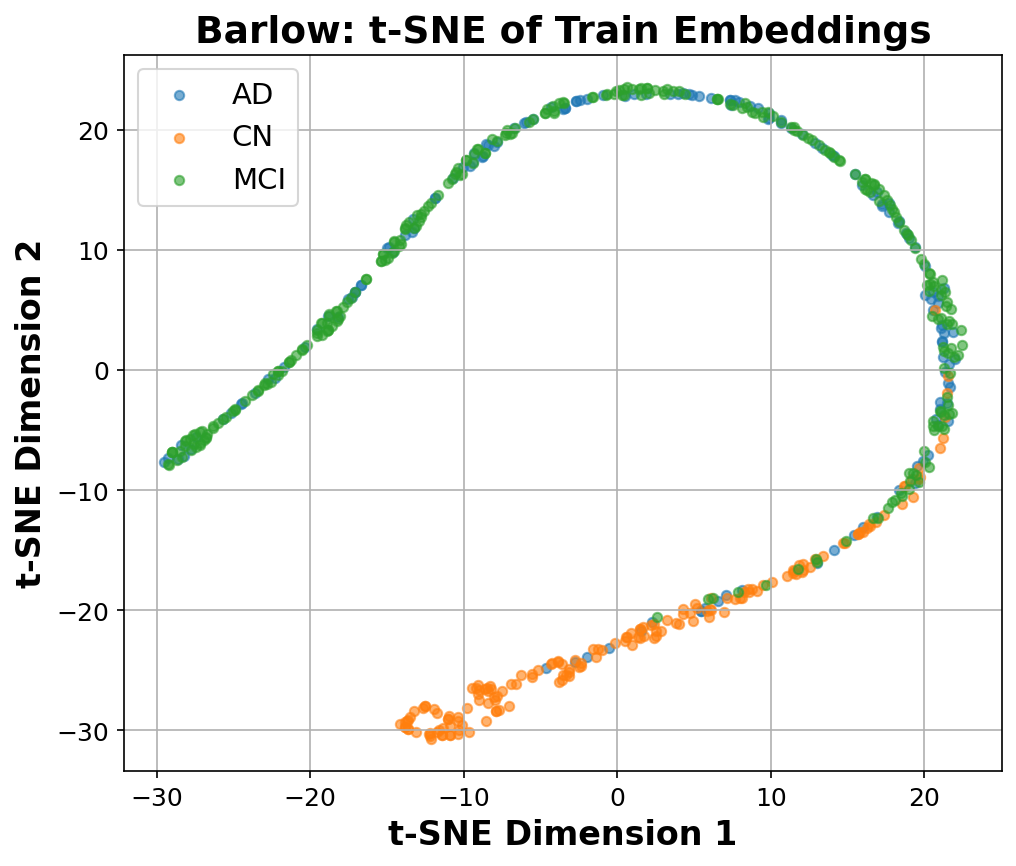

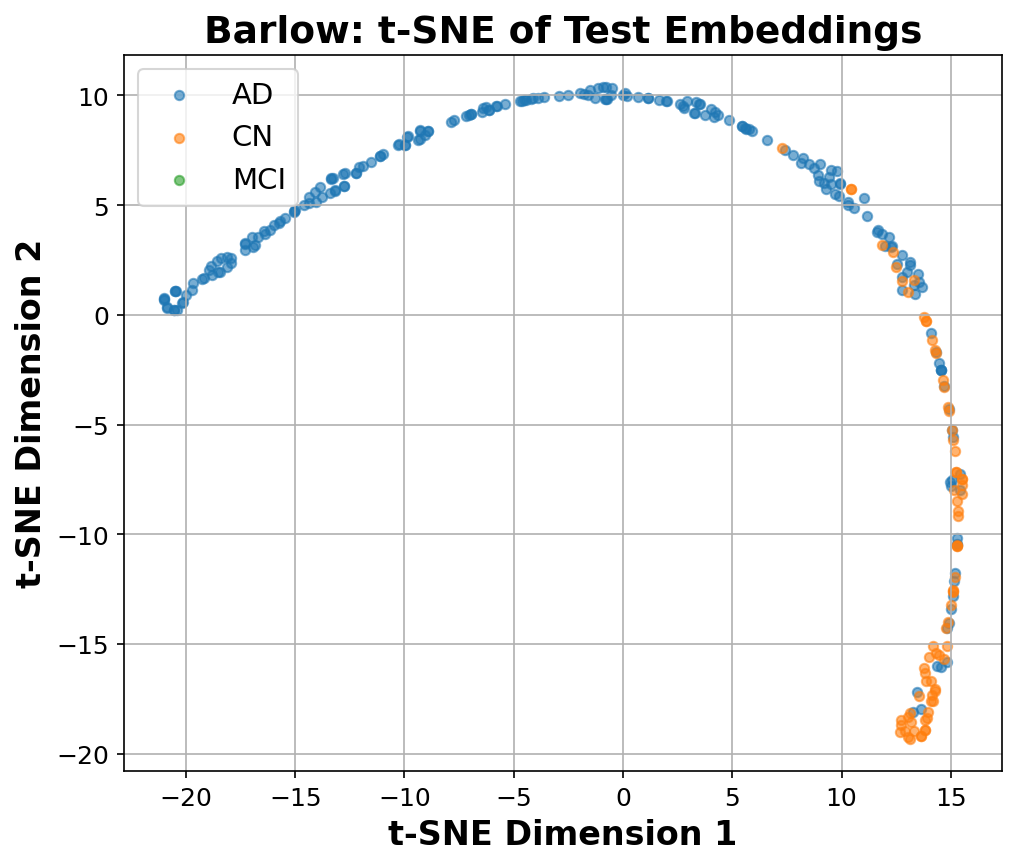

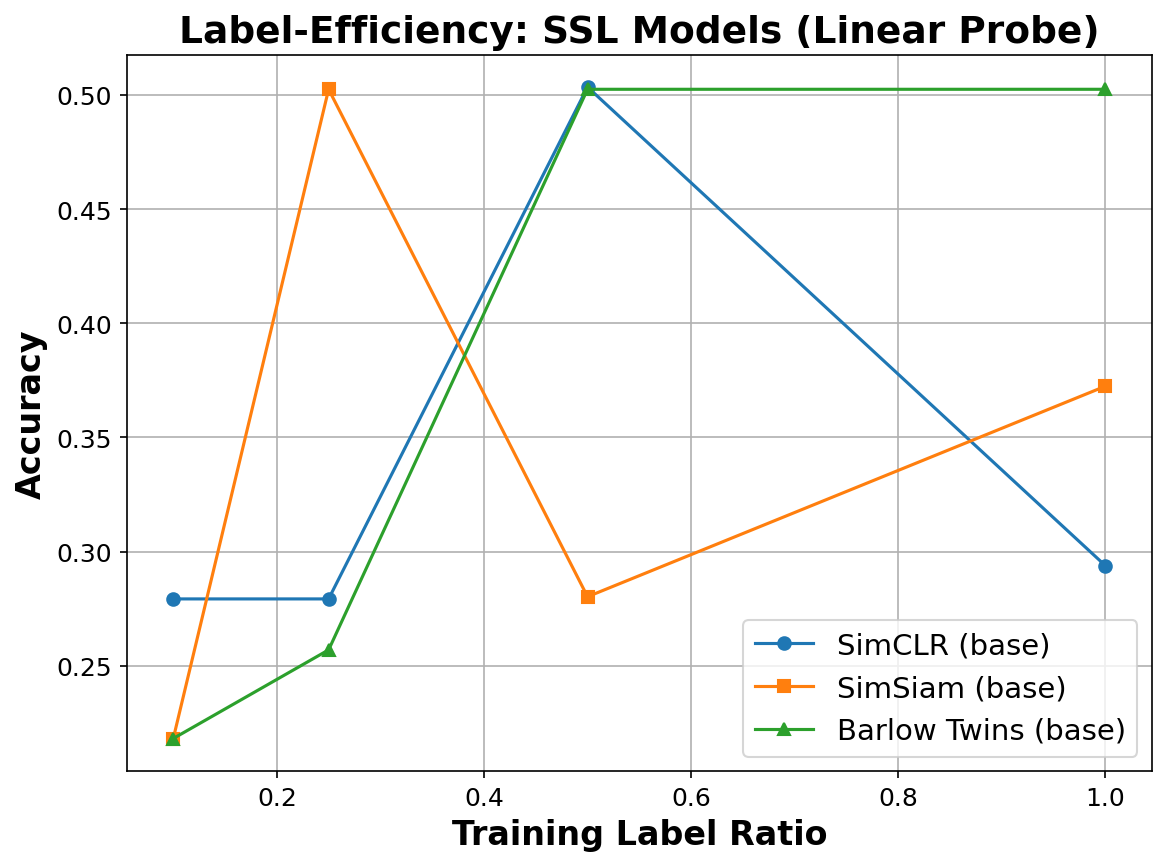

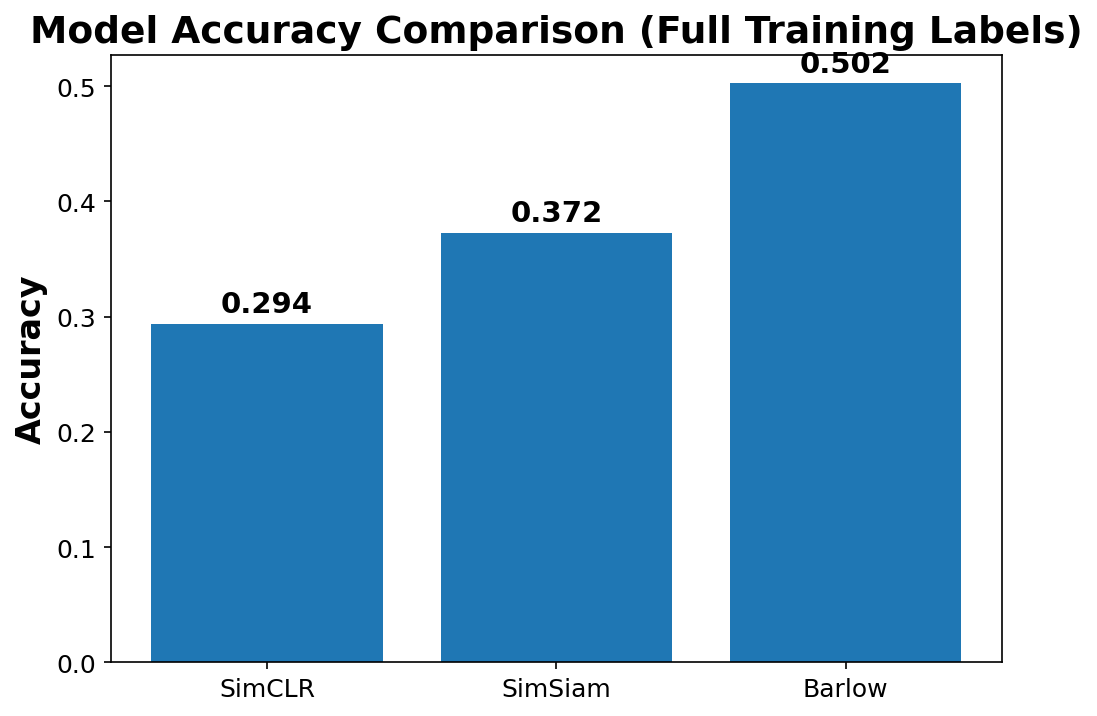

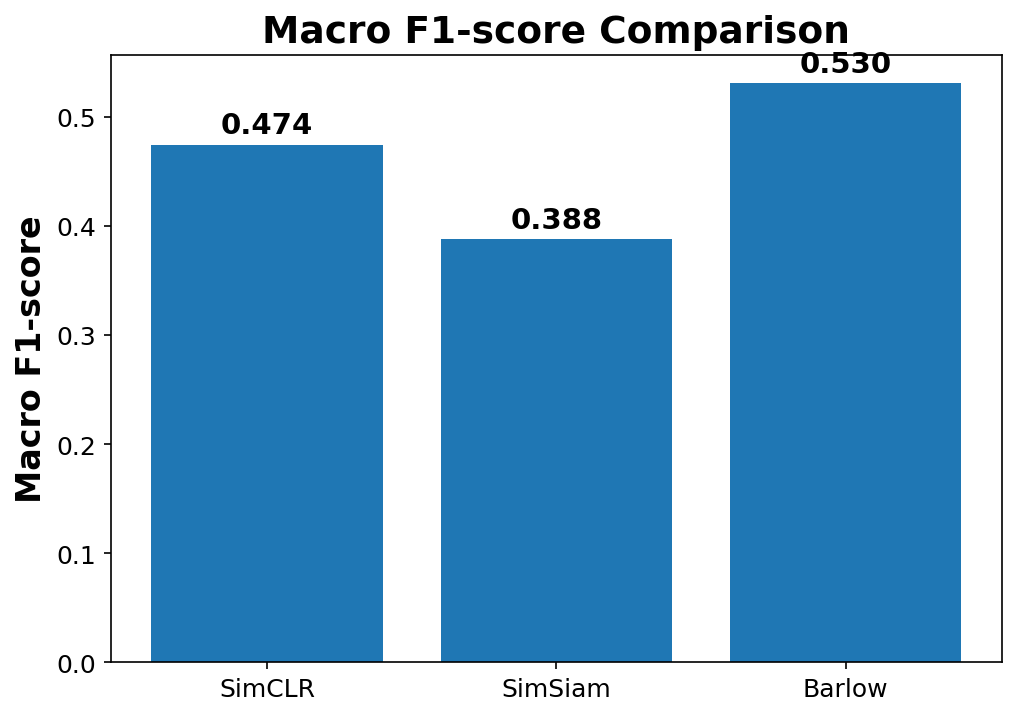

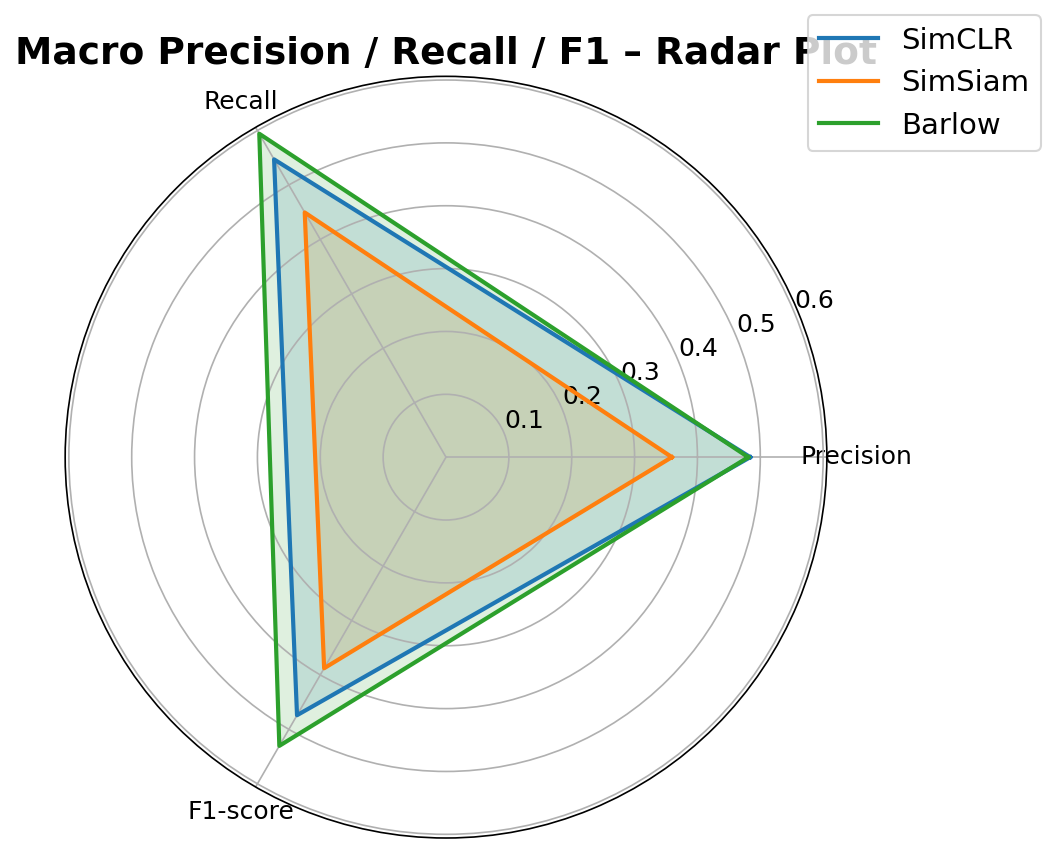

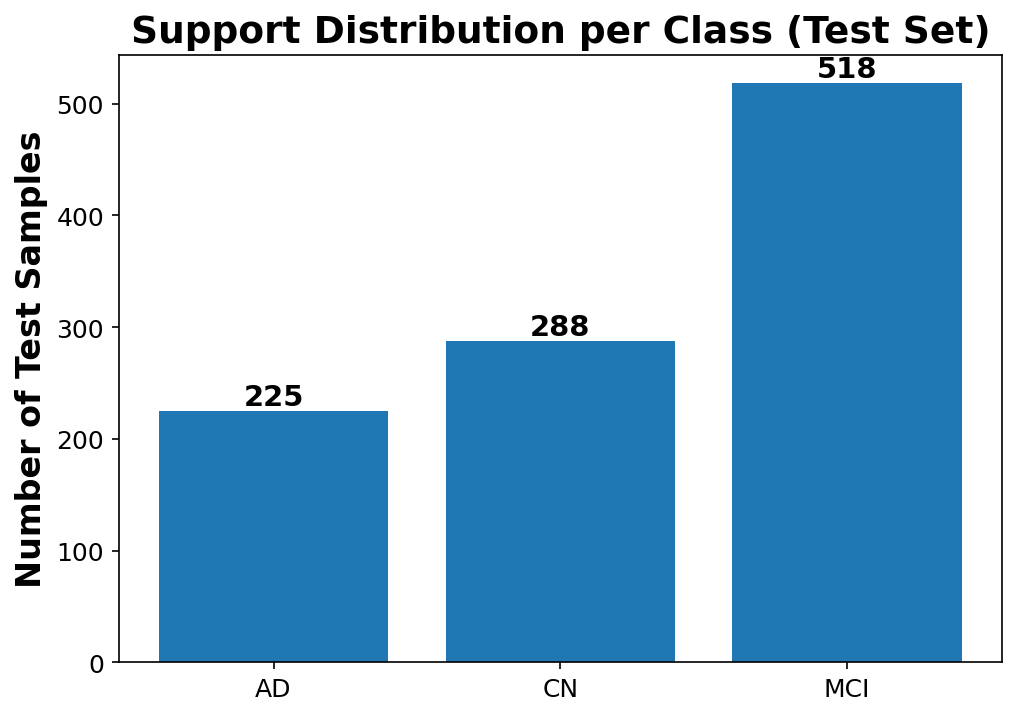

In [5]:
# ============================================================
# VISUALIZATIONS FOR IEEE PAPER – ALL 3 SSL MODELS (FIXED)
# ============================================================

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE

# ---------- GLOBAL MATPLOTLIB STYLE (BOLD / BIGGER FONTS) ----------
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "axes.labelweight": "bold",
    "legend.fontsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 150,
})

AUTOTUNE = tf.data.AUTOTUNE

# --------- MUST MATCH PREVIOUS CELLS (paths & configs) ----------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_root = "/kaggle/input/alzheimer-disease/train-20251010T183510Z-1-001/train"
test_root  = "/kaggle/input/alzheimer-disease/test-20251010T094612Z-1-001/test"

ssl_base_dir = "/kaggle/input/alzeihmer-disease-model/other/default/1"
SIMCLR_PATH  = os.path.join(ssl_base_dir, "alzheimer_ssl_2 SimCLRmodel.h5")
SIMSIAM_PATH = os.path.join(ssl_base_dir, "alzheimer_ssl_3 -Simsiammodel.h5")
BARLOW_PATH  = os.path.join(ssl_base_dir, "alzheimer_ssl_4- Barlow twinsmodel.h5")

# These come from your Task-7 cell:
# TRAIN_RATIOS, simclr_scores, simclr_abl_scores,
# simsiam_scores, simsiam_abl_scores, barlow_scores, barlow_abl_scores

# ---------- 1) DATA HELPERS (STREAMING) ----------
def make_full_train_ds(shuffle=True):
    ds = tf.keras.utils.image_dataset_from_directory(
        train_root,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=42,
    )
    return ds

def make_test_ds():
    ds = tf.keras.utils.image_dataset_from_directory(
        test_root,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )
    return ds.prefetch(AUTOTUNE)

tmp_ds = make_full_train_ds(shuffle=True)
class_names = tmp_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)
num_train_batches = tf.data.experimental.cardinality(tmp_ds).numpy()
print("Train batches per epoch:", num_train_batches)

def make_train_subset_ds(ratio):
    n_take = max(1, int(num_train_batches * ratio))
    ds = make_full_train_ds(shuffle=True)
    ds = ds.take(n_take).prefetch(AUTOTUNE)
    return ds

test_ds = make_test_ds()

# ---------- 2) CUSTOM LAYERS (same as before) ----------
from tensorflow.keras.layers import Layer

class L2Normalization(Layer):
    def __init__(self, axis=-1, **kwargs):
        super(L2Normalization, self).__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.nn.l2_normalize(inputs, axis=self.axis)

    def get_config(self):
        config = super().get_config()
        config.update({"axis": self.axis})
        return config

class IdentityLayer(Layer):
    def call(self, x):
        return x

custom_objects = {
    "L2Normalization": L2Normalization,
    "IdentityLayer": IdentityLayer,
}

# ---------- 3) LINEAR-PROBE BUILDER ----------
def build_linear_probe(ssl_model, num_classes=NUM_CLASSES):
    ssl_model.trainable = False
    input_shape = ssl_model.input_shape[1:]
    inputs = tf.keras.Input(shape=input_shape, name=ssl_model.name + "_lp_input")
    x = ssl_model(inputs, training=False)
    if len(x.shape) > 2:
        x = tf.keras.layers.GlobalAveragePooling2D(name=ssl_model.name + "_lp_gap")(x)
    outputs = tf.keras.layers.Dense(
        num_classes,
        activation="softmax",
        name=ssl_model.name + "_lp_head",
    )(x)
    return tf.keras.Model(inputs, outputs, name=ssl_model.name + "_linear_probe")

# ---------- 4) EMBEDDING COLLECTOR FOR t-SNE ----------
def collect_embeddings(dataset, feature_model, max_samples=600):
    """
    Collects feature embeddings using a feature_model (backbone+GAP),
    not the probe. Avoids Keras graph KeyError issues.
    """
    embs_list, labels_list = [], []
    count = 0
    for x_batch, y_batch in dataset:
        if count >= max_samples:
            break
        remaining = max_samples - count
        x_use = x_batch[:remaining]
        y_use = y_batch[:remaining]
        embs = feature_model.predict(x_use, verbose=0)
        embs_list.append(embs)
        labels_list.append(y_use.numpy())
        count += len(x_use)
    if not embs_list:
        return np.empty((0, feature_model.output_shape[-1])), np.array([])
    return np.vstack(embs_list), np.concatenate(labels_list)

# ---------- 5) TRAIN PROBE + COLLECT EVERYTHING FOR ONE MODEL ----------
def evaluate_model_full(
    model_name,
    model_path,
    train_ratio=1.0,
    epochs=6,
    lr=1e-3,
    optimizer_type="adam",
    max_train_tsne=600,
    max_test_tsne=300,
):
    print(f"\n=== Processing {model_name} (ratio={train_ratio}) ===")
    tf.keras.backend.clear_session()

    # train dataset (full ratio)
    train_ds_ratio = make_train_subset_ds(train_ratio)

    # load SSL model
    ssl_model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)
    ssl_model._name = model_name

    # build probe
    probe = build_linear_probe(ssl_model, NUM_CLASSES)

    if optimizer_type.lower() == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)

    probe.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    # train with validation on test_ds to get curves
    history = probe.fit(
        train_ds_ratio,
        epochs=epochs,
        validation_data=test_ds,
        verbose=0,
    )
    print(f"{model_name} – final val_accuracy: {history.history['val_accuracy'][-1]:.4f}")

    # predictions on full test set
    y_true, y_prob = [], []
    for x_batch, y_batch in test_ds:
        preds = probe.predict(x_batch, verbose=0)
        y_prob.append(preds)
        y_true.append(y_batch.numpy())
    y_prob = np.vstack(y_prob)
    y_true = np.concatenate(y_true)
    y_pred = np.argmax(y_prob, axis=1)

    # -------- feature extractor from SSL backbone (for t-SNE) --------
    x_feat = ssl_model.output
    if len(x_feat.shape) > 2:
        x_feat = tf.keras.layers.GlobalAveragePooling2D()(x_feat)
    feature_extractor = tf.keras.Model(ssl_model.input, x_feat, name=model_name + "_features")

    # collect train embeddings (subset)
    train_ds_for_embed = make_train_subset_ds(train_ratio)
    train_emb, train_labels_emb = collect_embeddings(
        train_ds_for_embed, feature_extractor, max_samples=max_train_tsne
    )

    # collect test embeddings (subset)
    test_emb, test_labels_emb = collect_embeddings(
        test_ds, feature_extractor, max_samples=max_test_tsne
    )

    # cleanup big models to free memory
    del feature_extractor, probe, ssl_model
    tf.keras.backend.clear_session()

    metrics = {
        "history": history.history,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "train_emb": train_emb,
        "train_labels_emb": train_labels_emb,
        "test_emb": test_emb,
        "test_labels_emb": test_labels_emb,
    }

    return metrics

# ---------- 6) RUN FOR ALL 3 SSL MODELS (BASE) ----------
models_info = [
    ("SimCLR",  SIMCLR_PATH),
    ("SimSiam", SIMSIAM_PATH),
    ("Barlow",  BARLOW_PATH),
]

all_metrics = {}

for name, path in models_info:
    all_metrics[name] = evaluate_model_full(
        model_name=name,
        model_path=path,
        train_ratio=1.0,
        epochs=6,
        lr=1e-3,
        optimizer_type="adam",
        max_train_tsne=600,
        max_test_tsne=300,
    )

# ============================================================
# A) TRAIN–VALIDATION CURVES FOR EACH MODEL
# ============================================================
for name, _ in models_info:
    hist = all_metrics[name]["history"]
    epochs_range = range(1, len(hist["loss"]) + 1)

    # Loss
    plt.figure(figsize=(7, 5))
    plt.plot(epochs_range, hist["loss"], marker="o", label="Training Loss")
    plt.plot(epochs_range, hist["val_loss"], marker="s", label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Cross-Entropy Loss")
    plt.title(f"{name}: Training vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Accuracy
    plt.figure(figsize=(7, 5))
    plt.plot(epochs_range, hist["accuracy"], marker="o", label="Training Accuracy")
    plt.plot(epochs_range, hist["val_accuracy"], marker="s", label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title(f"{name}: Training vs Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ============================================================
# B) CONFUSION MATRIX + CLASSIFICATION REPORT PER MODEL
# ============================================================
reports = {}  # store classification_report dicts

for name, _ in models_info:
    y_true = all_metrics[name]["y_true"]
    y_pred = all_metrics[name]["y_pred"]

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(NUM_CLASSES),
        yticks=np.arange(NUM_CLASSES),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel="True Label",
        xlabel="Predicted Label",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = cm_norm.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(
                j, i,
                f"{cm[i, j]}\n({cm_norm[i, j]:.2f})",
                ha="center",
                va="center",
                color="white" if cm_norm[i, j] > thresh else "black",
                fontweight="bold",
            )

    ax.set_title(f"{name}: Confusion Matrix (Normalized)")
    fig.tight_layout()
    plt.show()

    # classification report
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    reports[name] = report_dict
    report_df = pd.DataFrame(report_dict).transpose()
    print(f"\n=== Classification Report: {name} ===")
    display(report_df)

# ============================================================
# C) ROC CURVES (ONE-VS-REST) PER MODEL
# ============================================================
for name, _ in models_info:
    y_true = all_metrics[name]["y_true"]
    y_prob = all_metrics[name]["y_prob"]

    y_true_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(NUM_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.figure(figsize=(7, 6))
    plt.plot(
        fpr["micro"],
        tpr["micro"],
        label=f"Micro-average ROC (AUC = {roc_auc['micro']:.3f})",
        linewidth=2,
    )

    for i in range(NUM_CLASSES):
        plt.plot(
            fpr[i],
            tpr[i],
            linestyle="--",
            linewidth=1.5,
            label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})",
        )

    plt.plot([0, 1], [0, 1], "k:", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name}: Multi-Class ROC Curves")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ============================================================
# D) t-SNE PLOTS (TRAIN + TEST EMBEDDINGS) PER MODEL
# ============================================================
def tsne_plot(embeddings, labels, title, class_names):
    if embeddings.shape[0] == 0:
        print(f"[WARN] No embeddings for {title}")
        return
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="random",
        random_state=42,
    )
    emb_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(7, 6))
    for i, cls in enumerate(class_names):
        idx = labels == i
        plt.scatter(
            emb_2d[idx, 0],
            emb_2d[idx, 1],
            alpha=0.6,
            label=cls,
            s=20,
        )
    plt.title(title)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for name, _ in models_info:
    train_emb = all_metrics[name]["train_emb"]
    train_labels_emb = all_metrics[name]["train_labels_emb"]
    test_emb = all_metrics[name]["test_emb"]
    test_labels_emb = all_metrics[name]["test_labels_emb"]

    tsne_plot(train_emb, train_labels_emb, f"{name}: t-SNE of Train Embeddings", class_names)
    tsne_plot(test_emb,  test_labels_emb,  f"{name}: t-SNE of Test Embeddings",  class_names)

# ============================================================
# E) LABEL-EFFICIENCY CURVES (ACCURACY vs TRAIN RATIO)
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(TRAIN_RATIOS, simclr_scores, marker="o", label="SimCLR (base)")
plt.plot(TRAIN_RATIOS, simsiam_scores, marker="s", label="SimSiam (base)")
plt.plot(TRAIN_RATIOS, barlow_scores, marker="^", label="Barlow Twins (base)")

plt.xlabel("Training Label Ratio")
plt.ylabel("Accuracy")
plt.title("Label-Efficiency: SSL Models (Linear Probe)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# F) MODEL ACCURACY COMPARISON AT FULL LABELS
# ============================================================
full_accs = [
    simclr_scores[-1],
    simsiam_scores[-1],
    barlow_scores[-1],
]
model_labels = ["SimCLR", "SimSiam", "Barlow"]

plt.figure(figsize=(7, 5))
bars = plt.bar(np.arange(len(model_labels)), full_accs)
plt.xticks(np.arange(len(model_labels)), model_labels, rotation=0)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (Full Training Labels)")

for bar, acc in zip(bars, full_accs):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{acc:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

# ============================================================
# G) F1 SCORE COMPARISON (MACRO AVERAGE)
# ============================================================
macro_f1 = []
for name in model_labels:
    macro_f1.append(reports[name]["macro avg"]["f1-score"])

plt.figure(figsize=(7, 5))
bars = plt.bar(np.arange(len(model_labels)), macro_f1)
plt.xticks(np.arange(len(model_labels)), model_labels)
plt.ylabel("Macro F1-score")
plt.title("Macro F1-score Comparison")

for bar, f1 in zip(bars, macro_f1):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{f1:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
plt.tight_layout()
plt.show()

# ============================================================
# H) PRECISION & RECALL RADAR PLOT (MACRO METRICS)
# ============================================================
metrics_names = ["Precision", "Recall", "F1-score"]
num_metrics = len(metrics_names)

angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]  # close the loop

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

for name in model_labels:
    macro_prec = reports[name]["macro avg"]["precision"]
    macro_rec  = reports[name]["macro avg"]["recall"]
    macro_f1s  = reports[name]["macro avg"]["f1-score"]
    values = [macro_prec, macro_rec, macro_f1s]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=name)
    ax.fill(angles, values, alpha=0.15)

ax.set_thetagrids(np.degrees(angles[:-1]), metrics_names)
ax.set_title("Macro Precision / Recall / F1 – Radar Plot", fontweight="bold")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

# ============================================================
# I) SUPPORT DISTRIBUTION PLOT (TRUE CLASS COUNTS)
# ============================================================
any_report = reports[model_labels[0]]  # same test set, any model
supports = [any_report[cls]["support"] for cls in class_names]

plt.figure(figsize=(7, 5))
bars = plt.bar(np.arange(len(class_names)), supports)
plt.xticks(np.arange(len(class_names)), class_names, rotation=0)
plt.ylabel("Number of Test Samples")
plt.title("Support Distribution per Class (Test Set)")

for bar, sup in zip(bars, supports):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{int(sup)}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()


=== Ablation Accuracy Table ===


,Model,Variant,Train_Ratio,Accuracy
0,SimCLR,Base,0.10,0.279340
1,SimCLR,Ablation,0.10,0.266731
2,SimCLR,Base,0.25,0.279340
3,SimCLR,Ablation,0.25,0.569350
4,SimCLR,Base,0.50,0.503395
5,SimCLR,Ablation,0.50,0.234724
6,SimCLR,Base,1.00,0.293889
7,SimCLR,Ablation,1.00,0.961203
8,SimSiam,Base,0.10,0.218235
9,SimSiam,Ablation,0.10,0.279340



=== Paired t-tests Between Base SSL Models (Across Ratios) ===


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Comparison,t_stat,p_value,Cohen_d,Mean_SimCLR,Mean_SimSiam,Mean_Barlow
0,SimCLR vs SimSiam,-0.045720,0.966406,-0.022860,0.338991,0.343356,NaN
1,SimCLR vs Barlow,-0.513354,0.643118,-0.256677,0.338991,NaN,0.370029
2,SimSiam vs Barlow,-0.262819,0.809706,-0.131410,NaN,0.343356,0.370029



=== Base vs Ablation Statistics per SSL Model ===


,Model,Base_Mean_Acc,Ablation_Mean_Acc,Delta_Acc_(Abl-Base),Paired_t_stat,Paired_t_p,Wilcoxon_W,Wilcoxon_p,Cohen_d_(Abl-Base)
0,SimCLR,0.338991,0.508002,0.169011,-0.838530,0.463285,3.0,0.625,0.419265
1,SimSiam,0.343356,0.279340,-0.064016,1.036429,0.376212,2.0,0.375,-0.518215
2,Barlow,0.370029,0.343841,-0.026188,0.241192,0.824952,4.0,0.875,-0.120596



=== Friedman Test Across Base Models (SimCLR, SimSiam, Barlow) ===
Friedman Chi² = 0.4000, p = 0.818731

=== Nemenyi Post-hoc p-value Matrix (Base Models) ===


,SimCLR,SimSiam,Barlow
SimCLR,1.000000,0.856441,0.856441
SimSiam,0.856441,1.000000,1.000000
Barlow,0.856441,1.000000,1.000000


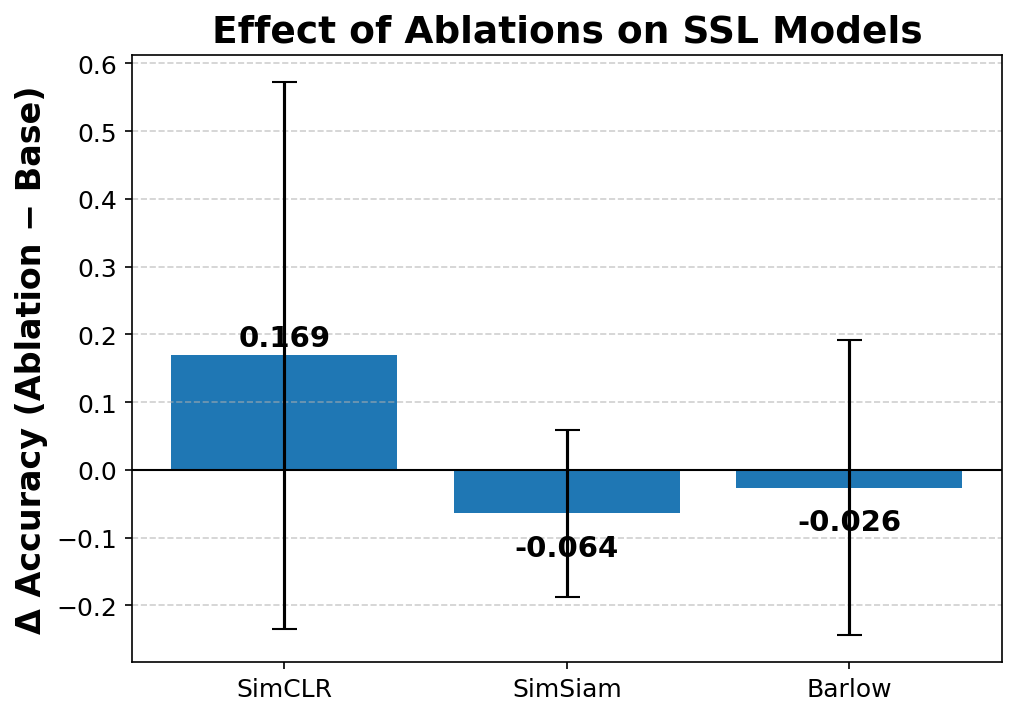

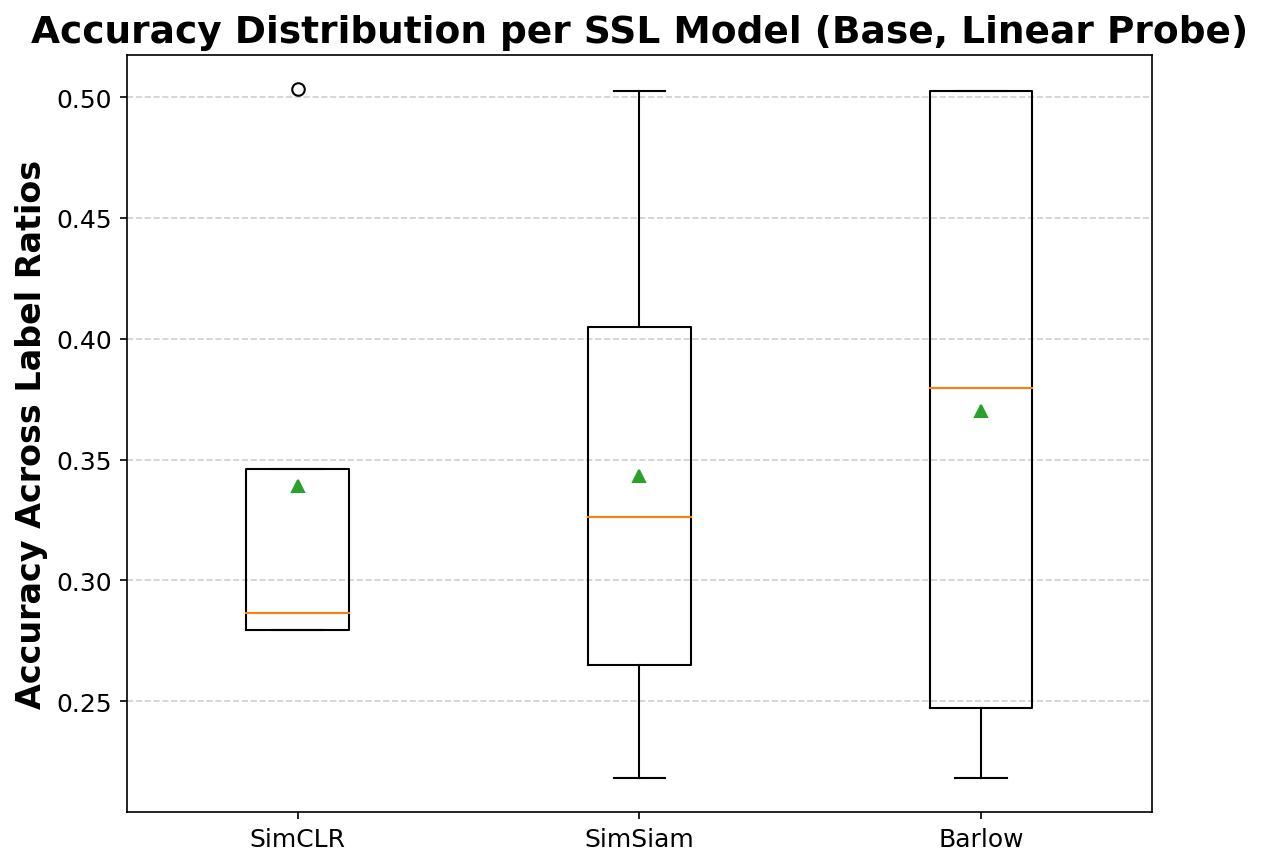

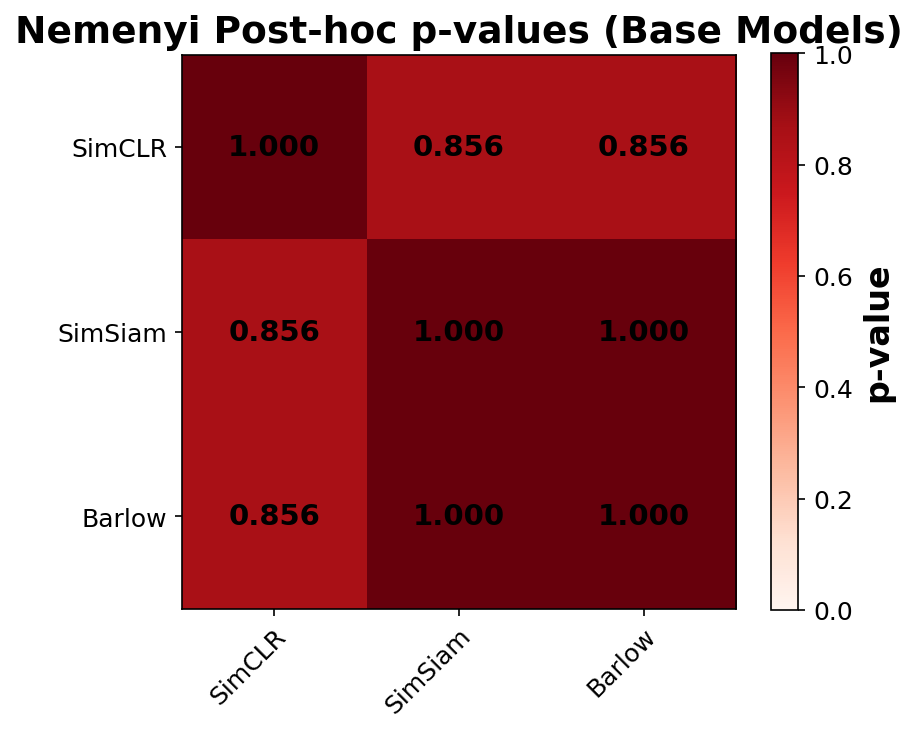

In [6]:
# ============================================================
# CONSOLIDATED RESULTS, STATS TESTS & EFFECT-SIZE FIGURES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import ttest_rel, wilcoxon, friedmanchisquare
import scikit_posthocs as sp

# ------------------------------------------------------------
# 0. ASSUMPTIONS FROM PREVIOUS CELLS
# ------------------------------------------------------------
# We assume this already exists from Task 7:
# - TRAIN_RATIOS: list of label ratios (e.g., [0.1, 0.25, 0.5, 1.0])
# - results: dict with keys:
#   "SimCLR", "SimCLR_abl", "SimSiam", "SimSiam_abl", "Barlow", "Barlow_abl"
#   each is a list of accuracies (one per ratio in TRAIN_RATIOS)

# For convenience, pull numpy arrays
simclr_scores      = np.array(results["SimCLR"])
simclr_abl_scores  = np.array(results["SimCLR_abl"])
simsiam_scores     = np.array(results["SimSiam"])
simsiam_abl_scores = np.array(results["SimSiam_abl"])
barlow_scores      = np.array(results["Barlow"])
barlow_abl_scores  = np.array(results["Barlow_abl"])

base_models = ["SimCLR", "SimSiam", "Barlow"]
base_scores = {
    "SimCLR": simclr_scores,
    "SimSiam": simsiam_scores,
    "Barlow": barlow_scores,
}
abl_scores = {
    "SimCLR": simclr_abl_scores,
    "SimSiam": simsiam_abl_scores,
    "Barlow": barlow_abl_scores,
}

# ---------- Matplotlib style ----------
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "axes.labelweight": "bold",
    "legend.fontsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 150,
})

# ------------------------------------------------------------
# 1. BUILD ABLATION TABLE (ACCURACIES PER RATIO)
# ------------------------------------------------------------
rows = []
for model in base_models:
    base = base_scores[model]
    abla = abl_scores[model]
    for i, ratio in enumerate(TRAIN_RATIOS):
        rows.append({
            "Model": model,
            "Variant": "Base",
            "Train_Ratio": ratio,
            "Accuracy": base[i],
        })
        rows.append({
            "Model": model,
            "Variant": "Ablation",
            "Train_Ratio": ratio,
            "Accuracy": abla[i],
        })

ablation_df = pd.DataFrame(rows)
print("=== Ablation Accuracy Table ===")
display(ablation_df)

# Optionally save
# ablation_df.to_csv("ablation_results_table.csv", index=False)

# ------------------------------------------------------------
# 2. PAIRED T-TESTS (ALL-MODEL COMPARISONS ON IDENTICAL FOLDS)
# ------------------------------------------------------------
def cohens_d(x, y):
    diff = x - y
    return diff.mean() / diff.std(ddof=1)

pair_results = []

for m1, m2 in combinations(base_models, 2):
    s1 = base_scores[m1]
    s2 = base_scores[m2]
    t_stat, p_val = ttest_rel(s1, s2)
    d = cohens_d(s1, s2)
    pair_results.append({
        "Comparison": f"{m1} vs {m2}",
        "t_stat": t_stat,
        "p_value": p_val,
        "Cohen_d": d,
        "Mean_{m1}".format(m1=m1): s1.mean(),
        "Mean_{m2}".format(m2=m2): s2.mean(),
    })

pair_tests_df = pd.DataFrame(pair_results)
print("\n=== Paired t-tests Between Base SSL Models (Across Ratios) ===")
display(pair_tests_df)

# ------------------------------------------------------------
# 3. BASE vs ABLATION: T-TEST + WILCOXON PER MODEL
# ------------------------------------------------------------
ba_rows = []
for model in base_models:
    base = base_scores[model]
    abla = abl_scores[model]

    t_stat, p_t = ttest_rel(base, abla)
    w_stat, p_w = wilcoxon(base, abla)
    d = cohens_d(abla, base)  # effect of ablation (abla - base)

    ba_rows.append({
        "Model": model,
        "Base_Mean_Acc": base.mean(),
        "Ablation_Mean_Acc": abla.mean(),
        "Delta_Acc_(Abl-Base)": (abla - base).mean(),
        "Paired_t_stat": t_stat,
        "Paired_t_p": p_t,
        "Wilcoxon_W": w_stat,
        "Wilcoxon_p": p_w,
        "Cohen_d_(Abl-Base)": d,
    })

base_ablation_stats_df = pd.DataFrame(ba_rows)
print("\n=== Base vs Ablation Statistics per SSL Model ===")
display(base_ablation_stats_df)

# ------------------------------------------------------------
# 4. FRIEDMAN TEST + NEMENYI (3+ MODELS)
# ------------------------------------------------------------
# Friedman on base models across the same "folds" (ratios)
fried_stat, fried_p = friedmanchisquare(
    simclr_scores,
    simsiam_scores,
    barlow_scores
)

print("\n=== Friedman Test Across Base Models (SimCLR, SimSiam, Barlow) ===")
print(f"Friedman Chi² = {fried_stat:.4f}, p = {fried_p:.6f}")

# Nemenyi post-hoc if needed
data_for_nemenyi = np.vstack([simclr_scores, simsiam_scores, barlow_scores]).T
nemenyi_matrix = sp.posthoc_nemenyi_friedman(data_for_nemenyi)
nemenyi_matrix.index = base_models
nemenyi_matrix.columns = base_models

print("\n=== Nemenyi Post-hoc p-value Matrix (Base Models) ===")
display(nemenyi_matrix)

# ------------------------------------------------------------
# 5. EFFECT-SIZE FIGURE 1: Δ Accuracy (Ablation - Base) PER MODEL
# ------------------------------------------------------------
delta_means = []
delta_stds = []
for model in base_models:
    delta = abl_scores[model] - base_scores[model]
    delta_means.append(delta.mean())
    delta_stds.append(delta.std(ddof=1))

plt.figure(figsize=(7, 5))
x = np.arange(len(base_models))
bars = plt.bar(x, delta_means, yerr=delta_stds, capsize=6)

plt.xticks(x, base_models)
plt.axhline(0.0, color="black", linewidth=1)
plt.ylabel("Δ Accuracy (Ablation − Base)")
plt.title("Effect of Ablations on SSL Models")

for bar, dm in zip(bars, delta_means):
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + (0.005 if h >= 0 else -0.03),
        f"{dm:.3f}",
        ha="center",
        va="bottom" if h >= 0 else "top",
        fontweight="bold",
    )

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. EFFECT-SIZE FIGURE 2: ACCURACY DISTRIBUTIONS (BOX PLOTS)
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
data_box = [base_scores[m] for m in base_models]
plt.boxplot(data_box, labels=base_models, showmeans=True)

plt.ylabel("Accuracy Across Label Ratios")
plt.title("Accuracy Distribution per SSL Model (Base, Linear Probe)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. OPTIONAL: HEATMAP-LIKE VIEW OF NEMENYI P-VALUES
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(nemenyi_matrix.values, cmap="Reds", vmin=0, vmax=1)

ax.set_xticks(np.arange(len(base_models)))
ax.set_yticks(np.arange(len(base_models)))
ax.set_xticklabels(base_models)
ax.set_yticklabels(base_models)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.set_title("Nemenyi Post-hoc p-values (Base Models)")

for i in range(len(base_models)):
    for j in range(len(base_models)):
        ax.text(
            j, i,
            f"{nemenyi_matrix.values[i, j]:.3f}",
            ha="center",
            va="center",
            color="black",
            fontweight="bold",
        )

fig.colorbar(im, ax=ax, label="p-value")
plt.tight_layout()
plt.show()
